# AIMLC ZG521 — Conversational AI · Group Assignment 1
## Problem Statement 2 — Study of Embedding Models and Approximate Nearest Neighbor Search: Semantic Quality vs Search Efficiency

**Group 129**






## Student Details

| Name | BITS ID | Email |
|---|---|---|
| Pushadapu Sanjay Kumar | 2025ae05898 | 2025ae05898@wilp.bits-pilani.ac.in |
| B Devchandraaj | 2025ae05469 | 2025ae05469@wilp.bits-pilani.ac.in |
| Gourob Nandi | 2025ae05503 | 2025ae05503@wilp.bits-pilani.ac.in |
| Anirudh Anand | 2025ae05576 | 2025ae05576@wilp.bits-pilani.ac.in |


We worked as a group on this assignment and divided the work by task so that each member contributed to a different part of the study.

## Group Contributions

| Student | Contribution area | Specific contribution |
|---|---|---|
| Pushadapu Sanjay Kumar  | Dataset and embedding | Dataset loading, validation, and embedding generation |
| B Devchandraaj| Similarity and exact kNN | Metric formulas, normalization analysis, and exact retrieval |
| Gourob Nandi | HNSW and IVF | FAISS index construction and ANN parameter sweeps |
| Anirudh Anand | Evaluation and reporting | Metrics, visualizations, qualitative examples, and report preparation |

## Architecture and Workflow

For each experiment, we used the same dataset, query set, document IDs, and qrels. The documents were encoded first and the queries were encoded when they were searched. We then compared exact nearest-neighbor search against HNSW and IVF so that the quality-latency trade-off could be studied fairly.

```text
SciFact corpus + queries + qrels
              |
      Validate and align IDs
              |
   +----------+-----------+
   |                      |
Encoder 1              Encoder 2
DistilBERT             BGE-large
   |                      |
Normalized vectors   Normalized vectors
   |                      |
   +----------+-----------+
              |
 Exact kNN / HNSW / IVF
              |
 Recall@5, latency, speedup,
 candidate estimates, examples
              |
       Final recommendation
```

Figure 1. Experimental workflow for the embedding and ANN comparison.


## Executive Summary

The goal of this assignment was to compare two embedding models and two ANN methods on the same retrieval task and measure the quality-latency trade-off. We used SciFact from BEIR, which contains 5,183 passages and 300 queries with relevance labels. This exceeds the assignment minimums and provides a reproducible scientific semantic-retrieval testbed.

The two embedding models were DistilBERT and BGE-large. DistilBERT is smaller and general-purpose, while BGE-large is a retrieval-tuned encoder. On the 300 labelled queries, BGE-large achieved exact Recall@5 `0.780` compared with DistilBERT's `0.108`. Cosine similarity was the most appropriate metric because it is scale-invariant; for the normalized vectors used here, cosine, dot product, and L2 produce the same ranking.

For ANN methods, HNSW and IVF were evaluated against the same exact baseline. HNSW `efSearch=16` gave the best latency-oriented balance: Recall@5 `0.770`, `0.036 ms/query`, and `31.54x` speedup. IVF `nprobe=20` also cleared the operational Recall@5 target with `0.769`, `0.148 ms/query`, and an average of `1105.8` measured selected-list vectors/query, making it the resource-constrained alternative. The qualitative comparison showed that the models often return different top results, so model selection materially changes retrieval behavior.

Overall, the recommended latency-oriented setup is BGE-large with normalized embeddings and HNSW `efSearch=16`. For a larger, memory-constrained deployment, IVF-PQ should be evaluated with a measured recall and optional exact reranking.

## Tools and Libraries Used

- **Python 3.XX.X** (recorded execution environment)
- `datasets` (Hugging Face) — loading the BEIR-format retrieval dataset
- `pandas`, `numpy` — data handling
- `sentence-transformers` — encoder embedding models (Task 2 onward)
- `faiss-cpu` — HNSW / IVF ANN indexes (Task 5 onward)
- `matplotlib` — plots (Task 6 onward)

Install all of the above with: `pip install -r requirements.txt` (see `ass-1/requirements.txt`).

---
## Executive Summary

This assignment compares embedding quality and ANN efficiency for scientific claim retrieval. The questions are which encoder gives better Recall@5 and how much latency can be reduced without losing too much quality.

SciFact from BEIR provides 5,183 passages, 300 labelled queries, and 339 qrels. Scientific claims and abstracts frequently use different wording and domain terminology, so this dataset tests semantic matching rather than simple keyword lookup.

BGE-large is a retrieval-tuned encoder and achieved exact Recall@5 `0.780`, versus `0.108` for general-purpose DistilBERT. On the BGE embeddings, cosine similarity is ranking-equivalent to dot product and L2 after normalization.

Against exact search, HNSW `efSearch=16` was the fastest tested configuration meeting the operational Recall@5 target of `0.75`: Recall@5 `0.770`, `0.036 ms/query`, and `31.54x` speedup. IVF `nprobe=20` also met the target at Recall@5 `0.769`; its measured average candidate pool was `1105.8` vectors/query, so it is the resource-constrained alternative. IVF-PQ is a further option for larger corpora when memory savings justify quantization and possible recall loss.

The final latency-oriented recommendation is BGE-large with normalized embeddings and HNSW `efSearch=16`; the Task 8 section describes when to choose IVF or a stronger recall setting.

## Environment Bootstrap (auto-install)

This cell makes the notebook self-contained: run it first and any missing package from `requirements.txt` is installed automatically into the current kernel. Safe to re-run — already-installed packages are skipped.

In [ ]:
# AUTO-INSTALL: install any required package that is missing in this kernel.
# Run this cell FIRST when opening the notebook standalone (e.g. in a virtual lab).
import importlib.util, subprocess, sys

# (import name that Python actually uses)  ->  (pip package name to install)
REQUIRED = {
    "datasets": "datasets",
    "pandas": "pandas",
    "numpy": "numpy",
    "sentence_transformers": "sentence-transformers",
    "huggingface_hub": "huggingface-hub",
    "faiss": "faiss-cpu",
    "matplotlib": "matplotlib",
    "truststore": "truststore",
}

missing = [pip_name for import_name, pip_name in REQUIRED.items()
           if importlib.util.find_spec(import_name) is None]

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("Done. If imports below fail, restart the kernel and run all cells.")
else:
    print("All required packages are already installed.")


All required packages are already installed.


In [ ]:
# Purpose: environment setup. Trusts the OS cert store and routes
# through the corporate proxy (fixes SSL errors on office/lab networks), then
# imports libraries and defines two reuse helpers used later: resolve_model()
# (use a local model copy if one exists, else download) and
# load_aligned_embeddings() (load saved embeddings, reordered by id).
import os

# macOS fix: torch and faiss-cpu both bundle their own OpenMP runtime;
# loading both in one process crashes the kernel silently (OMP: Error #15)
# unless this is set before either library is imported.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

try:
    import truststore
    truststore.inject_into_ssl()
except Exception:
    pass  # fine if unavailable -- only needed behind an SSL-inspecting proxy

import urllib.request
_proxy = urllib.request.getproxies().get("https") or urllib.request.getproxies().get("http")
if _proxy:
    os.environ["HTTP_PROXY"] = os.environ["HTTPS_PROXY"] = _proxy
    os.environ["http_proxy"] = os.environ["https_proxy"] = _proxy

import sys, time, json, random
import numpy as np
import pandas as pd

random.seed(129)   # Group 129 -- fixed seed for reproducibility
np.random.seed(129)


def _display_path(path, trailing_slash=False):
    """Format paths consistently in notebook messages without changing them."""
    display = str(path).replace("\\", "/").rstrip("/")
    return display + "/" if trailing_slash else display


def resolve_model(model_name):
    """Return a local model path, downloading it into models/ when needed."""
    os.makedirs("models", exist_ok=True)
    local = os.path.join("models", model_name.split("/")[-1])
    if os.path.isdir(local) and os.path.exists(os.path.join(local, "config.json")):
        print(f"[info] Using cached model: {_display_path(local, True)}")
        return local

    try:
        from huggingface_hub import snapshot_download
        print(f"[info] Downloading {model_name} into {_display_path(local, True)} ...")
        snapshot_download(
            repo_id=model_name,
            local_dir=local
        )
        print(f"[info] Model cached in {_display_path(local, True)}")
        return local
    except Exception as exc:
        # SentenceTransformer can still use its standard Hugging Face cache.
        print(f"[warning] Could not cache {model_name} locally: {exc!r}")
        print("[info] Falling back to the Hugging Face model ID.")
        return model_name


def load_aligned_embeddings(emb_path, id_path, wanted_ids):
    """Load a saved embedding array, reordered to match wanted_ids (via the
    id file saved alongside it), so row order never has to be assumed."""
    emb = np.load(emb_path)
    if os.path.exists(id_path):
        saved_ids = [str(x) for x in json.load(open(id_path))]
        pos = {sid: i for i, sid in enumerate(saved_ids)}
        emb = emb[[pos[str(w)] for w in wanted_ids]]
    return emb


print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy :", np.__version__)


Python: 3.14.5
pandas: 3.0.5
numpy : 2.5.2


---
# Task 1 — Corpus and Query Dataset Preparation 

**Dataset chosen: `SciFact`** (BEIR benchmark; Thakur et al., 2021 / Wadden et al., 2020) — a publicly available dataset that ships a document corpus, a query set, and query-document relevance labels together, matching this task's requirement exactly. Corpus (~5,183 passages) and queries (~300) both clear the 1,000/50 minimums.


In [ ]:
# Purpose: load SciFact (corpus/queries/qrels). Uses the local
# data/raw/ copy if present (no network needed -- works behind a proxy that
# blocks the Hub); otherwise downloads from Hugging Face. Queries are then
# filtered to only those with a relevance judgment.
import os
import pandas as pd

RAW_FILES = ("corpus.jsonl", "queries.jsonl", "qrels.tsv")


def _find_data_raw():
    """First data/raw directory (checked relative to cwd, then one level up)
    that already contains all three raw files, or None."""
    # Check the common notebook locations so the same notebook works from
    # the assignment folder, its parent folder, or a hosted lab workspace.
    for base in (os.path.join("data", "raw"), os.path.join("..", "data", "raw"),
                 os.path.join("ass-1", "data", "raw")):
        if all(os.path.exists(os.path.join(base, file_name)) for file_name in RAW_FILES):
            return base
    return None


def load_beir_scifact():
    """Load SciFact from local data/raw if present, else the Hugging Face
    Hub. Queries are filtered to those with >=1 relevance judgment."""
    local_dir = _find_data_raw()
    if local_dir is not None:
        # Read the local cache first so rerunning the notebook is reproducible
        # and does not depend on network access.
        corpus_df = pd.read_json(os.path.join(local_dir, "corpus.jsonl"), lines=True)
        queries_df = pd.read_json(os.path.join(local_dir, "queries.jsonl"), lines=True)
        qrels_df = pd.read_csv(os.path.join(local_dir, "qrels.tsv"), sep="\t")
        # Standard BEIR files use _id/query-id/corpus-id/score; the rest of
        # this notebook uses explicit, stable names.
        corpus_df = corpus_df.rename(columns={"_id": "doc_id", "corpus-id": "doc_id"})
        queries_df = queries_df.rename(columns={"_id": "query_id", "query-id": "query_id"})
        qrels_df = qrels_df.rename(columns={
            "query-id": "query_id", "corpus-id": "doc_id", "score": "relevance"
        })
        # Use forward slashes in the message so the displayed path is portable
        # across Windows and POSIX without changing the actual file path.
        display_dir = local_dir.replace("\\", "/").rstrip("/") + "/"
        print(f"[info] Loaded SciFact from local files: {display_dir}")
    else:
        # Use the Hugging Face copies only when all required local files are absent.
        from datasets import load_dataset
        corpus_df = load_dataset("BeIR/scifact", "corpus", split="corpus").to_pandas().rename(columns={"_id": "doc_id"})
        queries_df = load_dataset("BeIR/scifact", "queries", split="queries").to_pandas().rename(columns={"_id": "query_id"})
        qrels_df = load_dataset("BeIR/scifact-qrels", split="test").to_pandas()
        qrels_df.columns = ["query_id", "doc_id", "relevance"]
        print("[info] Downloaded SciFact from the Hugging Face Hub.")

    # IDs must be strings on both sides, or later merges/lookups silently fail.
    # This creates one consistent key type for corpus, queries, and qrels.
    corpus_df["doc_id"] = corpus_df["doc_id"].astype(str)
    queries_df["query_id"] = queries_df["query_id"].astype(str)
    qrels_df["query_id"] = qrels_df["query_id"].astype(str)
    qrels_df["doc_id"] = qrels_df["doc_id"].astype(str)

    # Keep only queries with >=1 relevance judgment (standard BEIR practice).
    # Without a qrel, a query cannot contribute to Recall@5 evaluation.
    labelled_ids = set(qrels_df["query_id"].unique())
    before = len(queries_df)
    queries_df = queries_df[queries_df["query_id"].isin(labelled_ids)].reset_index(drop=True)
    if before - len(queries_df):
        print(f"[info] Dropped {before - len(queries_df)} queries with no relevance judgment "
              f"(kept {len(queries_df)}, all with >=1 qrel).")

    # Cache a first-time internet download so later runs work offline.
    if local_dir is None:
        cache_dir = os.path.join("data", "raw")
        os.makedirs(cache_dir, exist_ok=True)
        corpus_df.to_json(os.path.join(cache_dir, "corpus.jsonl"), orient="records", lines=True)
        queries_df.to_json(os.path.join(cache_dir, "queries.jsonl"), orient="records", lines=True)
        qrels_df.to_csv(os.path.join(cache_dir, "qrels.tsv"), sep="\t", index=False)
        print(f"[info] Cached downloaded SciFact files in {_display_path(cache_dir, True)}")

    return corpus_df, queries_df, qrels_df


# These three DataFrames become the common input for every later experiment.
corpus_df, queries_df, qrels_df = load_beir_scifact()
DATA_DIR = _find_data_raw() or os.path.join("data", "raw")
print(f"corpus  : {len(corpus_df)} passages")
print(f"queries : {len(queries_df)} queries (all with >=1 relevance judgment)")
print(f"qrels   : {len(qrels_df)} relevance judgments")


[info] Loaded SciFact from local files: data/raw/
corpus  : 5183 passages
queries : 300 queries (all with >=1 relevance judgment)
qrels   : 339 relevance judgments


In [ ]:
# Purpose: check the loaded data against the assignment's stated
# minimums (>=1,000 passages, >=50 queries, every query labelled) and stop
# the notebook immediately (via assert) if either minimum isn't met.
MIN_CORPUS, MIN_QUERIES = 1000, 50

meets_corpus_min = len(corpus_df) >= MIN_CORPUS
meets_query_min = len(queries_df) >= MIN_QUERIES

print(f"Corpus  >= {MIN_CORPUS}: {meets_corpus_min}  ({len(corpus_df)} passages)")
print(f"Queries >= {MIN_QUERIES}: {meets_query_min}  ({len(queries_df)} queries)")
print(f"Every query has >=1 relevance judgment: "
      f"{queries_df['query_id'].isin(qrels_df['query_id']).all()}")

assert meets_corpus_min, "Corpus below the 1,000-passage minimum"
assert meets_query_min, "Query set below the 50-query minimum"
print("\n[OK] SciFact data clears both minimums.")


Corpus  >= 1000: True  (5183 passages)
Queries >= 50: True  (300 queries)
Every query has >=1 relevance judgment: True

[OK] SciFact data clears both minimums.


In [ ]:
# Purpose: show the schema of each of the three tables (corpus, queries,
# qrels) without dumping full passage text, so the structure is visible.
print("=== Sample corpus passage (text truncated) ===")
_row = corpus_df.iloc[0].to_dict()
_row["text"] = _row["text"][:200] + " ..."
print(_row)

print("\n=== Sample query ===")
print(queries_df.iloc[0].to_dict())

print("\n=== Sample relevance judgments (qrels) ===")
print(qrels_df.head())


=== Sample corpus passage (text truncated) ===
{'doc_id': '4983', 'title': 'Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic resonance imaging.', 'text': 'Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities. A line scan diffusion-weighted magnetic re ...'}

=== Sample query ===
{'query_id': '1', 'title': '', 'text': '0-dimensional biomaterials show inductive properties.'}

=== Sample relevance judgments (qrels) ===
  query_id    doc_id  relevance
0        1  31715818          1
1        3  14717500          1
2        5  13734012          1
3       13   1606628          1
4       36   5152028          1


In [ ]:
# Purpose: write corpus/queries/qrels to the resolved data/raw
# directory (DATA_DIR, set in the load cell above) so Tasks 2+ can load the
# exact same fixed dataset without re-downloading or re-running this cell.
import os

# Reuse the directory resolved in the load cell; default to ./data/raw if this
# cell is ever run on its own.
DATA_DIR = globals().get("DATA_DIR", os.path.join("data", "raw"))
os.makedirs(DATA_DIR, exist_ok=True)

corpus_df.to_json(os.path.join(DATA_DIR, "corpus.jsonl"), orient="records", lines=True)
queries_df.to_json(os.path.join(DATA_DIR, "queries.jsonl"), orient="records", lines=True)
qrels_df.to_csv(os.path.join(DATA_DIR, "qrels.tsv"), sep="\t", index=False)

# Match the portable path format used by the dataset-loading message.
display_dir = str(DATA_DIR).replace("\\", "/").rstrip("/") + "/"
print(f"Saved to {display_dir}: corpus.jsonl, queries.jsonl, qrels.tsv")


Saved to data/raw/: corpus.jsonl, queries.jsonl, qrels.tsv


### Dataset Details and Source

- **Name:** SciFact (BEIR benchmark; biomedical / scientific-claim verification)
- **Citation:** Wadden et al., *Fact or Fiction: Verifying Scientific Claims*, EMNLP 2020; redistributed by Thakur et al., *BEIR*, NeurIPS 2021
- **Source:** https://huggingface.co/datasets/BeIR/scifact (corpus + queries), https://huggingface.co/datasets/BeIR/scifact-qrels (relevance judgments)
- **Size:** 5,183 corpus passages, 300 queries (each with >=1 relevance judgment), binary relevance
- **Format:** corpus = `{doc_id, title, text}`; queries = `{query_id, text}`; qrels = `{query_id, doc_id, relevance}`

### Why SciFact Is a Good Semantic Retrieval Testbed

Each query is a scientific claim and each candidate passage is a scientific abstract that may support or refute it. Relevant claims and abstracts often express the same idea with different wording, abbreviations, and biomedical terminology, so matching exact keywords is not sufficient. The corpus also contains many plausible scientific distractors, making it useful for testing whether an embedding model captures meaning rather than only surface form. The qrels provide reproducible query-document ground truth for Recall@5 instead of relying on subjective manual inspection.

### Explanation of the Logic Used

`load_beir_scifact()` downloads corpus/queries/qrels from Hugging Face and normalizes IDs to a common schema. Queries are filtered to only those with a qrel - the raw split ships 1,109 queries but just 300 have a relevance judgment, so filtering makes "relevance information for each query" literally true.

### Justification for the Chosen Approach

The assignment explicitly permits "an existing dataset containing query-document relevance labels" - BEIR datasets bundle exactly that, avoiding hand-built (and inconsistent) relevance judgments. SciFact combines semantic paraphrase, domain terminology, dense scientific distractors, and binary evidence labels in one reproducible retrieval benchmark.

### Inference

Corpus and queries clear the assignment minimums by ~5x and ~6x respectively, leaving room to subsample later if needed. The 809 dropped queries simply have no qrel in this split - expected, not a data quality issue.


---
# Task 2 - Embedding Generation and Pooling

**Two encoder models, chosen for contrasting profiles:**

1. `distilbert-base-uncased` (Sanh et al., 2019) - general-purpose distilled BERT, **mean pooling**, not fine-tuned for retrieval.
2. `BAAI/bge-large-en-v1.5` (Xiao et al., 2023) - trained specifically for retrieval via contrastive fine-tuning, **[CLS]-token pooling**.

## Why encoder models are appropriate

For an input sequence with tokens $x_1, ..., x_T$, an encoder produces contextual representations

$$
h_i = \operatorname{Encoder}(x_1, ..., x_T)_i,
$$

where each $h_i$ can use information from tokens on both sides. In one self-attention head, with input matrix $X$ and learned projection matrices $W_Q$, $W_K$, and $W_V$,

$$
Q = XW_Q, \qquad K = XW_K, \qquad V = XW_V,
$$

$$
\operatorname{Attention}(X) = \operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V.
$$

Encoder self-attention uses a bidirectional mask, so every non-padding token may attend to other visible tokens in the sequence. A sentence vector is then formed by pooling, for example $z = h_{[CLS]}$ or $z = \frac{1}{T}\sum_{i=1}^{T} h_i$.

A decoder-only transformer uses the same attention calculation with a causal mask $C$ added to the logits:

$$
C_{ij} = \begin{cases}0, & j \le i \\ -\infty, & j > i\end{cases}, \qquad
\operatorname{CausalAttention}(X) = \operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + C\right)V.
$$

Thus token $i$ cannot use future tokens $x_{i+1}, ..., x_T$. A decoder-only model is excellent for next-token generation, but an encoder is a more direct fit for retrieval because it summarizes the complete query and document before their vectors are compared.

The retrieval architecture is a bi-encoder: $z_q = f_q(q)$ and $z_d = f_d(d)$ are computed separately, then scored with $s(q,d) = z_q^T z_d$. Document vectors can therefore be encoded once offline and reused for many queries. A cross-encoder would compute $g(q,d)$ for every query-document pair at request time, which is usually too expensive for scanning a large corpus.

BGE's contrastive retrieval training further encourages relevant query-passage pairs to be close and non-relevant pairs to be separated. DistilBERT provides a useful general-purpose baseline, while BGE tests the benefit of retrieval-specific training and larger representation capacity.


In [ ]:
# Purpose: for each model, record documented facts (architecture, training objective,
# dimension, pooling, max length), then embed the corpus + queries. Saves embeddings
# to data/results/ and reuses them on later runs (no model/network needed once
# generated). Records execution status without fabricating results when a model is unavailable.
import gc
import os, json, time
import numpy as np
import pandas as pd

# Keep model metadata in one place so the experiment table and cache validation
# use the same dimensions, pooling descriptions, and input-length limits.
MODEL_SPECS = {
    "distilbert-base-uncased": {
        "architecture": "Encoder-only Transformer (DistilBERT)",
        "training_objective": "General masked-language-model pre-training; not retrieval fine-tuned",
        "pooling": "mean pooling",
        "dim": 768,
        "max_input_length": 512,
        "retrieval_suitability": "General semantic baseline; pooling is added for sentence embeddings",
    },
    "BAAI/bge-large-en-v1.5": {
        "architecture": "Encoder-only Transformer (BERT-style)",
        "training_objective": "Contrastive retrieval fine-tuning for query-passage similarity",
        "pooling": "[CLS] token pooling",
        "dim": 1024,
        "max_input_length": 512,
        "retrieval_suitability": "Purpose-built dense retrieval encoder",
    },
}

os.makedirs("data/results", exist_ok=True)
# Convert the DataFrame columns to lists because SentenceTransformer.encode
# accepts a sequence of texts and returns one vector per input text.
corpus_texts = corpus_df["text"].tolist()
query_texts = queries_df["text"].tolist()
doc_ids = corpus_df["doc_id"].astype(str).tolist()
query_ids = queries_df["query_id"].astype(str).tolist()

try:
    import torch
    DEVICE = "cpu"
except ImportError:
    torch = None
    DEVICE = "cpu"

BATCH_SIZE = 32
CPU_THREADS = min(12, os.cpu_count() or 1)
if torch is not None:
    torch.set_num_threads(CPU_THREADS)
print(f"[Task 2] device={DEVICE}, batch_size={BATCH_SIZE}, cpu_threads={CPU_THREADS}")

TIMINGS_PATH = "data/results/task2_timings.json"
try:
    timings = json.load(open(TIMINGS_PATH, encoding="utf-8")) if os.path.exists(TIMINGS_PATH) else {}
except (OSError, json.JSONDecodeError):
    timings = {}


def _cache_is_usable(emb_path, expected_rows, expected_dim, expected_ids, id_path):
    """Reject stale or incomplete arrays before attempting aligned loading."""
    if not (os.path.exists(emb_path) and os.path.exists(id_path)):
        return False
    try:
        # mmap reads only the array header here, avoiding a full load during
        # the cache check; the complete array is loaded only after validation.
        shape = np.load(emb_path, mmap_mode="r").shape
        saved_ids = [str(x) for x in json.load(open(id_path, encoding="utf-8"))]
    except (OSError, ValueError, json.JSONDecodeError):
        return False
    return shape == (expected_rows, expected_dim) and set(saved_ids) == set(expected_ids)


def _generate_model(model_name, spec):
    """Load one model, embed corpus + queries sequentially, time each pass."""
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer(resolve_model(model_name), device=DEVICE)
    model.max_seq_length = spec["max_input_length"]
    try:
        # Encode documents and queries separately because they are evaluated
        # independently at search time. The timings show the cost of each pass.
        t0 = time.perf_counter()
        doc_emb = model.encode(corpus_texts, batch_size=BATCH_SIZE, convert_to_numpy=True,
                                normalize_embeddings=False, show_progress_bar=True)
        doc_elapsed = time.perf_counter() - t0
        print(f"    Documents complete in {doc_elapsed:.1f}s")

        t1 = time.perf_counter()
        qry_emb = model.encode(query_texts, batch_size=BATCH_SIZE, convert_to_numpy=True,
                                normalize_embeddings=False, show_progress_bar=True)
        qry_elapsed = time.perf_counter() - t1
        print(f"    Queries complete in {qry_elapsed:.1f}s")
        return {"doc_emb": doc_emb, "qry_emb": qry_emb,
                "documents_s": doc_elapsed, "queries_s": qry_elapsed}
    finally:
        # Release the model before the next model is loaded, which keeps memory
        # use bounded when both encoders are run in one notebook kernel.
        del model
        gc.collect()
        if torch is not None and DEVICE == "cuda":
            torch.cuda.empty_cache()


model_records = {}
for model_name, spec in MODEL_SPECS.items():
    print(f"=== {model_name} ===")
    safe = model_name.replace("/", "__")
    doc_path = f"data/results/embeddings_{safe}.npy"
    qry_path = f"data/results/query_embeddings_{safe}.npy"
    cache_ready = (
        _cache_is_usable(doc_path, len(doc_ids), spec["dim"], doc_ids, "data/results/doc_ids.json")
        and _cache_is_usable(qry_path, len(query_ids), spec["dim"], query_ids, "data/results/query_ids.json")
    )
    if cache_ready:
        # Reorder cached rows by ID so later matrix operations always match the
        # current DataFrame order, even if the source files were rearranged.
        doc_emb = load_aligned_embeddings(doc_path, "data/results/doc_ids.json", doc_ids)
        qry_emb = load_aligned_embeddings(qry_path, "data/results/query_ids.json", query_ids)
        elapsed = timings.get(model_name, {}).get("documents_s")
        model_records[model_name] = {"elapsed": elapsed}
        print(f"  Loaded saved embeddings: docs={doc_emb.shape}, queries={qry_emb.shape}")
        continue

    try:
        result = _generate_model(model_name, spec)
    except Exception as exc:
        print(f"  [warning] Could not run this model here: {exc!r}")
        print("  Fix: install sentence-transformers + internet access, then re-run.")
        model_records[model_name] = {"elapsed": None}
        continue

    doc_emb, qry_emb = result["doc_emb"], result["qry_emb"]
    # Save vectors and their IDs together. The IDs make the binary arrays
    # self-describing and allow safe alignment when they are loaded later.
    np.save(doc_path, doc_emb)
    np.save(qry_path, qry_emb)
    json.dump(doc_ids, open("data/results/doc_ids.json", "w", encoding="utf-8"))
    json.dump(query_ids, open("data/results/query_ids.json", "w", encoding="utf-8"))
    timings[model_name] = {"documents_s": round(result["documents_s"], 2),
                            "queries_s": round(result["queries_s"], 2), "device": DEVICE,
                            "batch_size": BATCH_SIZE, "cpu_threads": CPU_THREADS,
                            "max_seq_length": spec["max_input_length"],
                            "parallel_models": False, "parallel_batches": False,
                            "batch_workers": 1, "chunk_size": None}
    json.dump(timings, open(TIMINGS_PATH, "w", encoding="utf-8"), indent=2)
    model_records[model_name] = {"elapsed": result["documents_s"]}
    print(f"  Generated + saved: docs={doc_emb.shape}, queries={qry_emb.shape}, "
          f"time={result['documents_s']:.1f}s")

# Build a compact comparison table from documented architecture/objective facts
# and measured execution time. Missing timings remain explicit instead of invented.
comparison_rows = []
for model_name, spec in MODEL_SPECS.items():
    elapsed = model_records.get(model_name, {}).get("elapsed")
    comparison_rows.append({
        "Model name": model_name,
        "Architecture": spec["architecture"],
        "Training objective": spec["training_objective"],
        "Embedding dimension": spec["dim"],
        "Max input length (tokens)": spec["max_input_length"],
        "Pooling strategy": spec["pooling"],
        "Retrieval suitability": spec["retrieval_suitability"],
        "Document embedding time (s)": round(float(elapsed), 2) if elapsed is not None else None,
        "Timing status": "Executed" if elapsed is not None else "Execution required before submission",
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


[Task 2] device=cpu, batch_size=32, cpu_threads=12
=== distilbert-base-uncased ===
  Loaded saved embeddings: docs=(5183, 768), queries=(300, 768)
=== BAAI/bge-large-en-v1.5 ===
  Loaded saved embeddings: docs=(5183, 1024), queries=(300, 1024)


,Model name,Architecture,Training objective,Embedding dimension,Max input length (tokens),Pooling strategy,Retrieval suitability,Document embedding time (s),Timing status
0,distilbert-base-uncased,Encoder-only Transformer (DistilBERT),General masked-language-model pre-training; no...,768,512,mean pooling,General semantic baseline; pooling is added fo...,341.12,Executed
1,BAAI/bge-large-en-v1.5,Encoder-only Transformer (BERT-style),Contrastive retrieval fine-tuning for query-pa...,1024,512,[CLS] token pooling,Purpose-built dense retrieval encoder,2034.55,Executed


### Explanation of the Logic Used

Model name, dimension, max input length, and pooling strategy are documented facts from each model's official card (`MODEL_SPECS`) - no execution needed. The embeddings and timing require real execution: the loop encodes each model's corpus and queries sequentially, timing each pass with `time.perf_counter()`, and reuses saved arrays from `data/results/` on later runs so the expensive model pass only happens once. Device (CUDA vs CPU) is auto-detected.

### Justification for the Chosen Models

DistilBERT and BGE-large differ on exactly the axis this problem statement asks about: DistilBERT is smaller/faster and general-purpose, BGE-large is larger/slower and purpose-built for retrieval - and they use different pooling strategies (mean vs `[CLS]`), which is itself a required "for each model, document..." item. This gives Task 7 a real, explainable axis of disagreement rather than two near-identical models.

### Inference

BGE-large's larger dimension (1024 vs 768) and contrastive/RetroMAE training are expected to separate semantically related and unrelated passages more cleanly than DistilBERT - the concrete evidence for this is Task 7's side-by-side comparison, not asserted here.


---
# Task 3 — Similarity Metric Comparison 

**Model used: `BAAI/bge-large-en-v1.5`** — the retrieval-purpose-built model from Task 2, so the metric comparison reflects an embedding space actually optimized for semantic search (DistilBERT's general-purpose space would make this a less meaningful comparison).

**Pair selection (≥20 pairs required):** 5 randomly sampled queries × (all relevant documents from `qrels` + 4 random distractors each). SciFact queries typically have 1–2 relevant documents, giving ≥25 total pairs across 5 queries — enough per query to compare *rankings*, not just isolated scores.


In [ ]:
# Purpose: implement the three similarity/distance metrics
# directly from their mathematical definitions (not by calling an opaque
# library function), so the formulas are visible and auditable.
import numpy as np


def cosine_similarity(a, b):
    """cos(theta) = (a . b) / (||a|| * ||b||)"""
    a_norm, b_norm = np.linalg.norm(a), np.linalg.norm(b)
    if np.isclose(a_norm, 0.0) or np.isclose(b_norm, 0.0):
        raise ValueError("Cosine similarity is undefined for a zero vector")
    return float(np.dot(a, b) / (a_norm * b_norm))


def dot_product(a, b):
    """a . b = sum_i a_i * b_i"""
    return float(np.dot(a, b))


def l2_distance(a, b):
    """||a - b||_2 = sqrt(sum_i (a_i - b_i)^2)"""
    return float(np.linalg.norm(a - b))


print("[OK] Cosine, dot-product, and L2 formulas are defined for the metric experiment.")

[OK] Cosine, dot-product, and L2 formulas are defined for the metric experiment.


In [ ]:
# Purpose: build the query-document pairs used for Task 3.
# For each of 5 randomly sampled queries, pair it with all relevant
# documents from qrels plus 4 random non-relevant distractors. Sorting the
# relevant IDs makes the saved experiment deterministic across Python runs.
import random
random.seed(129)

MODEL_FOR_TASK3 = "BAAI/bge-large-en-v1.5"
N_QUERIES, N_DISTRACTORS = 5, 4

sample_queries = queries_df.sample(n=N_QUERIES, random_state=129).reset_index(drop=True)
all_doc_ids = corpus_df["doc_id"].tolist()

pairs = []
for _, q in sample_queries.iterrows():
    qid, qtext = q["query_id"], q["text"]

    # Include all known relevant documents and sample only non-relevant distractors.
    relevant_ids = set(
        qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"].astype(str)
    )
    distractor_pool = [d for d in all_doc_ids if d not in relevant_ids]
    distractors = random.sample(
        distractor_pool, min(N_DISTRACTORS, len(distractor_pool))
    )
    doc_ids_for_query = sorted(relevant_ids) + sorted(distractors)

    for did in doc_ids_for_query:
        text = corpus_df.loc[corpus_df["doc_id"] == did, "text"].values[0]
        pairs.append({"query_id": qid, "query_text": qtext, "doc_id": did,
                      "doc_text": text, "is_relevant": did in relevant_ids})

pairs_df = pd.DataFrame(pairs)
print(f"Selected {len(pairs_df)} query-document pairs across {pairs_df['query_id'].nunique()} "
      f"queries (>= 20 required).")

Selected 25 query-document pairs across 5 queries (>= 20 required).


In [ ]:
# Purpose: get an embedding for each pair's query/document, then
# compute cosine, dot product, and L2 for every pair. Reuses Task 2's saved
# embeddings for MODEL_FOR_TASK3 if they exist (no model/network needed);
# otherwise embeds the selected pairs directly. Per-query ranks are added
# explicitly so metric agreement can be inspected rather than inferred.
import os
import numpy as np
import pandas as pd

_safe = MODEL_FOR_TASK3.replace("/", "__")
_doc_path = f"data/results/embeddings_{_safe}.npy"
_qry_path = f"data/results/query_embeddings_{_safe}.npy"
metrics_df = q_emb = d_emb = None


def _compute_metrics(q_emb, d_emb):
    rows = []
    for i in range(len(pairs_df)):
        a, b = q_emb[i], d_emb[i]
        rows.append({
            "query_id": pairs_df.loc[i, "query_id"],
            "doc_id": pairs_df.loc[i, "doc_id"],
            "is_relevant": pairs_df.loc[i, "is_relevant"],
            "cosine": cosine_similarity(a, b),
            "dot_product": dot_product(a, b),
            "l2_distance": l2_distance(a, b),
        })

    result = pd.DataFrame(rows)
    # Rank within each query: higher cosine/dot is better, lower L2 is better.
    result["rank_cosine"] = result.groupby("query_id")["cosine"].rank(
        ascending=False, method="min"
    ).astype(int)
    result["rank_dot_product"] = result.groupby("query_id")["dot_product"].rank(
        ascending=False, method="min"
    ).astype(int)
    result["rank_l2"] = result.groupby("query_id")["l2_distance"].rank(
        ascending=True, method="min"
    ).astype(int)
    return result


if os.path.exists(_doc_path) and os.path.exists(_qry_path):
    doc_emb_all = load_aligned_embeddings(_doc_path, "data/results/doc_ids.json", corpus_df["doc_id"])
    qry_emb_all = load_aligned_embeddings(_qry_path, "data/results/query_ids.json", queries_df["query_id"])
    doc_idx = {d: i for i, d in enumerate(corpus_df["doc_id"].tolist())}
    qry_idx = {q: i for i, q in enumerate(queries_df["query_id"].tolist())}
    q_emb = np.stack([qry_emb_all[qry_idx[pairs_df.loc[i, "query_id"]]] for i in range(len(pairs_df))])
    d_emb = np.stack([doc_emb_all[doc_idx[pairs_df.loc[i, "doc_id"]]] for i in range(len(pairs_df))])
    metrics_df = _compute_metrics(q_emb, d_emb)
    print(f"Reused saved {MODEL_FOR_TASK3} embeddings for {len(metrics_df)} pairs.")
    display(metrics_df.sort_values(["query_id", "rank_cosine"])[[
        "query_id", "doc_id", "is_relevant", "cosine", "dot_product", "l2_distance",
        "rank_cosine", "rank_dot_product", "rank_l2"
    ]].round(5))
else:
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(resolve_model(MODEL_FOR_TASK3))
        q_emb = model.encode(pairs_df["query_text"].tolist(), show_progress_bar=True)
        d_emb = model.encode(pairs_df["doc_text"].tolist(), show_progress_bar=True)
        metrics_df = _compute_metrics(q_emb, d_emb)
        print(f"Computed cosine/dot/L2 for {len(metrics_df)} pairs using {MODEL_FOR_TASK3}.")
        display(metrics_df.sort_values(["query_id", "rank_cosine"])[[
            "query_id", "doc_id", "is_relevant", "cosine", "dot_product", "l2_distance",
            "rank_cosine", "rank_dot_product", "rank_l2"
        ]].round(5))
    except Exception as e:
        print(f"[warning] Could not run {MODEL_FOR_TASK3} here: {e!r}")
        print("Run Task 2 first to create saved embeddings, then re-run this cell.")

Reused saved BAAI/bge-large-en-v1.5 embeddings for 25 pairs.


,query_id,doc_id,is_relevant,cosine,dot_product,l2_distance,rank_cosine,rank_dot_product,rank_l2
20,1359,11614737,True,0.86643,0.86643,0.51685,1,1,1
22,1359,27024392,False,0.55394,0.55394,0.94452,2,2,2
21,1359,25440070,False,0.54089,0.54089,0.95823,3,3,3
23,1359,43192375,False,0.46888,0.46888,1.03065,4,4,4
24,1359,6144969,False,0.45009,0.45009,1.04872,5,5,5
5,1362,8290953,True,0.58409,0.58409,0.91204,1,1,1
8,1362,17119869,False,0.49833,0.49833,1.00167,2,2,2
9,1362,22025252,False,0.48994,0.48994,1.01001,3,3,3
6,1362,10795340,False,0.47708,0.47708,1.02266,4,4,4
7,1362,154763124,False,0.44160,0.44160,1.05679,5,5,5


In [ ]:
# Purpose: two checks required by Task 3.
#   1) Ranking comparison -- for each query, does sorting its 5 candidate
#      docs by cosine give the same order as sorting by dot product / L2?
#      Also prints the raw embedding norms, since dot product only diverges
#      from cosine when vector norms actually vary across documents.
#   2) Normalization effect -- re-normalize the same embeddings to unit
#      length and confirm the textbook identities: dot(a,b) == cosine(a,b)
#      and ||a-b||^2 == 2 - 2*cosine(a,b) once vectors have length 1.
if metrics_df is not None:
    doc_norms = np.linalg.norm(d_emb, axis=1)
    print(f"Raw document embedding norms: mean={doc_norms.mean():.4f}, std={doc_norms.std():.4f} "
          f"(dot product can only disagree with cosine if this std is non-trivial)\n")

    print("=== Ranking comparison per query (raw, unnormalized embeddings) ===")
    n_changed = 0
    for qid, group in metrics_df.groupby("query_id"):
        cos_rank = group.sort_values("cosine", ascending=False)["doc_id"].tolist()
        dot_rank = group.sort_values("dot_product", ascending=False)["doc_id"].tolist()
        l2_rank = group.sort_values("l2_distance", ascending=True)["doc_id"].tolist()  # smaller distance = closer
        changed = not (cos_rank == dot_rank == l2_rank)
        n_changed += changed
        print(f"query {qid}: cosine==dot ranking? {cos_rank == dot_rank}  |  "
              f"cosine==L2 ranking? {cos_rank == l2_rank}")
    print(f"Summary: ranking changed across metrics for {n_changed}/{metrics_df['query_id'].nunique()} queries.\n")

    print("=== Normalization effect: recompute dot/L2 on unit-normalized embeddings ===")
    def normalize(v):
        return v / np.linalg.norm(v)

    norm_rows = []
    for i in range(len(pairs_df)):
        a, b = normalize(q_emb[i]), normalize(d_emb[i])
        norm_rows.append({
            "query_id": pairs_df.loc[i, "query_id"],
            "doc_id": pairs_df.loc[i, "doc_id"],
            "dot_normalized": dot_product(a, b),
            "l2_normalized": l2_distance(a, b),
        })
    norm_df = pd.DataFrame(norm_rows).merge(
        metrics_df[["query_id", "doc_id", "cosine"]], on=["query_id", "doc_id"])
    # These two columns should both end up all-True -- that's the mathematical
    # identity for unit-normalized vectors, verified here on real numbers
    norm_df["dot_matches_cosine"] = np.isclose(norm_df["dot_normalized"], norm_df["cosine"], atol=1e-4)
    norm_df["l2sq_matches_2_minus_2cos"] = np.isclose(
        norm_df["l2_normalized"] ** 2, 2 - 2 * norm_df["cosine"], atol=1e-4)
    print(f"Summary: identity held for {norm_df['dot_matches_cosine'].sum()}/{len(norm_df)} pairs (dot) "
          f"and {norm_df['l2sq_matches_2_minus_2cos'].sum()}/{len(norm_df)} pairs (L2).")
else:
    print("Skipped -- needs metrics_df from the cell above (requires live model access).")


Raw document embedding norms: mean=1.0000, std=0.0000 (dot product can only disagree with cosine if this std is non-trivial)

=== Ranking comparison per query (raw, unnormalized embeddings) ===
query 1359: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 1362: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 185: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 660: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 743: cosine==dot ranking? True  |  cosine==L2 ranking? True
Summary: ranking changed across metrics for 0/5 queries.

=== Normalization effect: recompute dot/L2 on unit-normalized embeddings ===
Summary: identity held for 25/25 pairs (dot) and 25/25 pairs (L2).


In [ ]:
# Purpose: normalization experiment on genuinely UN-normalized vectors.
# BGE-large's embeddings come out already unit-length, so normalization has no
# visible effect there (a valid finding, but nothing to observe). DistilBERT's
# mean-pooled embeddings are NOT normalized (their norms vary), so the SAME 25
# pairs reveal a real divergence between dot-product and cosine rankings that
# normalization then removes -- demonstrating exactly WHEN normalization matters.
import os
import numpy as np

_DEMO = "distilbert-base-uncased"
_dsafe = _DEMO.replace("/", "__")
_ddoc = f"data/results/embeddings_{_dsafe}.npy"
_dqry = f"data/results/query_embeddings_{_dsafe}.npy"

if metrics_df is not None and os.path.exists(_ddoc) and os.path.exists(_dqry):
    _doc_all = load_aligned_embeddings(_ddoc, "data/results/doc_ids.json", corpus_df["doc_id"])
    _qry_all = load_aligned_embeddings(_dqry, "data/results/query_ids.json", queries_df["query_id"])
    _didx = {d: i for i, d in enumerate(corpus_df["doc_id"].tolist())}
    _qidx = {q: i for i, q in enumerate(queries_df["query_id"].tolist())}
    dq = np.stack([_qry_all[_qidx[pairs_df.loc[i, "query_id"]]] for i in range(len(pairs_df))])
    dd = np.stack([_doc_all[_didx[pairs_df.loc[i, "doc_id"]]] for i in range(len(pairs_df))])

    dn = np.linalg.norm(dd, axis=1)
    print(f"{_DEMO}: raw document-vector norms mean={dn.mean():.3f}, std={dn.std():.3f} "
          f"(range {dn.min():.2f}-{dn.max():.2f}) -- genuinely un-normalized.\n")

    demo = pd.DataFrame([{
        "query_id": pairs_df.loc[i, "query_id"],
        "doc_id": pairs_df.loc[i, "doc_id"],
        "cosine": cosine_similarity(dq[i], dd[i]),
        "dot_product": dot_product(dq[i], dd[i]),
        "l2_distance": l2_distance(dq[i], dd[i]),
    } for i in range(len(pairs_df))])

    print("=== RAW (un-normalized) ranking comparison per query ===")
    n_diff = 0
    for qid, g in demo.groupby("query_id"):
        cr = g.sort_values("cosine", ascending=False)["doc_id"].tolist()
        dr = g.sort_values("dot_product", ascending=False)["doc_id"].tolist()
        lr = g.sort_values("l2_distance")["doc_id"].tolist()
        n_diff += (cr != dr)
        print(f"query {qid}: cosine==dot ranking? {cr == dr}  |  cosine==L2 ranking? {cr == lr}")
    print(f"Summary: dot-product ranking DIFFERS from cosine for {n_diff}/{demo['query_id'].nunique()} "
          f"queries -- purely because the raw vector norms vary.\n")

    print("=== After L2-normalization (unit vectors) ===")
    okd = okl = 0
    for i in range(len(pairs_df)):
        a = dq[i] / np.linalg.norm(dq[i]); b = dd[i] / np.linalg.norm(dd[i])
        okd += bool(np.isclose(dot_product(a, b), demo.loc[i, "cosine"], atol=1e-4))
        okl += bool(np.isclose(l2_distance(a, b) ** 2, 2 - 2 * demo.loc[i, "cosine"], atol=1e-4))
    print(f"dot(a,b) == cosine(a,b) held for {okd}/{len(pairs_df)} pairs")
    print(f"||a-b||^2 == 2 - 2*cosine held for {okl}/{len(pairs_df)} pairs")
    print("\nConclusion: when norms vary (DistilBERT) normalization changes the dot-product "
          "ranking to agree with cosine; when vectors are already unit-length (BGE) it has no "
          "effect. This is the practical reason retrieval systems normalize before using dot product.")
else:
    print("Skipped -- needs metrics_df (cell above) and DistilBERT embeddings from Task 2.")


distilbert-base-uncased: raw document-vector norms mean=7.851, std=0.313 (range 7.42-8.56) -- genuinely un-normalized.

=== RAW (un-normalized) ranking comparison per query ===
query 1359: cosine==dot ranking? False  |  cosine==L2 ranking? True
query 1362: cosine==dot ranking? False  |  cosine==L2 ranking? False
query 185: cosine==dot ranking? False  |  cosine==L2 ranking? True
query 660: cosine==dot ranking? True  |  cosine==L2 ranking? False
query 743: cosine==dot ranking? False  |  cosine==L2 ranking? False
Summary: dot-product ranking DIFFERS from cosine for 4/5 queries -- purely because the raw vector norms vary.

=== After L2-normalization (unit vectors) ===
dot(a,b) == cosine(a,b) held for 25/25 pairs
||a-b||^2 == 2 - 2*cosine held for 25/25 pairs

Conclusion: when norms vary (DistilBERT) normalization changes the dot-product ranking to agree with cosine; when vectors are already unit-length (BGE) it has no effect. This is the practical reason retrieval systems normalize before 

### Explanation of the Logic Used

All three metrics are implemented directly from their mathematical definitions (see the Task 3 docstrings), not called as opaque library functions. The experiment evaluates 25 sampled query-document pairs across five reproducibly selected queries. The displayed score and rank columns make the comparison auditable: rank 1 is the highest value for cosine/dot product and the lowest value for L2 distance. The results therefore describe this sample rather than full-corpus metric rankings.

The normalization cells re-embed nothing - they unit-normalize the same vectors and recompute, isolating normalization as the only variable. Raw embedding-norm statistics are printed alongside each ranking comparison, since dot product can diverge from cosine when document norms vary.

### Mathematical Rationale

For nonzero vectors $a$ and $b$, cosine similarity is

$$
\cos(a,b) = \frac{a \cdot b}{\lVert a \rVert_2\lVert b \rVert_2}.
$$

For positive rescaling factors $\alpha$ and $\beta$,

$$
\cos(\alpha a, \beta b)
= \frac{\alpha\beta(a \cdot b)}{(\alpha\lVert a \rVert_2)(\beta\lVert b \rVert_2)}
= \cos(a,b).
$$

Thus cosine ignores positive vector magnitude and measures direction. If $\lVert a \rVert_2 = \lVert b \rVert_2 = 1$, then

$$
a \cdot b = \cos(a,b),
$$

and

$$
\lVert a-b \rVert_2^2
= (a-b)\cdot(a-b)
= \lVert a \rVert_2^2 + \lVert b \rVert_2^2 - 2a\cdot b
= 2 - 2\cos(a,b).
$$

Therefore, on unit-normalized vectors, maximizing cosine or dot product is equivalent to minimizing L2 distance. The code verifies these identities on the actual sampled embeddings.

### Justification for the Chosen Approach

Comparing rankings, rather than only raw scores, answers whether the metric changes retrieval order. The selected model, BGE-large, emits unit-length vectors, so the experiment verifies the identities `dot(a-hat,b-hat) = cos(a,b)` and `||a-hat-b-hat||^2 = 2 - 2*cos(a,b)` numerically on the actual embeddings. Cosine is selected based on its scale-invariance and these equivalence properties; separate Recall@5 values for each metric are not claimed here.

### The normalization experiment (two models, on purpose)

The selected model, **BGE-large, emits already unit-length vectors** (`sentence-transformers` applies the model's normalization module): norm `mean=1.0000, std=0.0000`. So for BGE the dot-product, cosine, and L2 rankings are identical for **0/5** queries changed - normalization has nothing left to change. That is a valid finding for the selected retrieval model.

To demonstrate when normalization matters, the same pairs are re-scored with **DistilBERT's mean-pooled embeddings**, whose raw norms vary. There, dot-product rankings differ from cosine for 4/5 sampled queries, while normalization makes dot product equal cosine and makes squared L2 equal `2 - 2*cosine` for all 25 pairs.

| | Dot-product vs cosine ranking |
|---|---|
| **Raw (un-normalized) DistilBERT** | **differs for 4/5 queries** - norms vary, so dot product rewards magnitude as well as direction |
| **After L2-normalization** | `dot == cosine` and `||a-b||^2 == 2-2*cos` for **all 25 pairs** |

### Inference

When vector norms vary, metric choice can change ranking: dot product includes magnitude, while cosine ignores it. Normalizing to unit length collapses the three measures onto the same ordering (dot becomes cosine; ascending L2 matches descending cosine). When vectors are already unit-length, the choice is ranking-equivalent. These conclusions are based on the sampled Task 3 pairs and should not be generalized to every corpus without a broader evaluation.


---
# Task 4 — Exact kNN Baseline 

**Model used: `BAAI/bge-large-en-v1.5`** — continuing with the retrieval-tuned model from Task 3 for consistency, so Tasks 4-6's baseline and ANN comparisons all measure the same embedding space. Task 7 brings DistilBERT back in for the cross-model comparison.

**Metric: cosine similarity** — per Task 3's finding that dot product and L2 give identical rankings to cosine once embeddings are unit-normalized, cosine is used directly as the ranking criterion.


In [ ]:
# Purpose: load the full BGE-large corpus + query embeddings
# (reusing Task 2's saved arrays, or generating them if Task 2 wasn't run for
# real yet), aligned to corpus_df / queries_df row order.
import os
import numpy as np

BASELINE_MODEL = "BAAI/bge-large-en-v1.5"
_safe = BASELINE_MODEL.replace("/", "__")
_doc_path = f"data/results/embeddings_{_safe}.npy"
_qry_path = f"data/results/query_embeddings_{_safe}.npy"

doc_emb = qry_emb = None
if os.path.exists(_doc_path) and os.path.exists(_qry_path):
    # Load the cached vectors and use the saved IDs to match every vector to
    # the correct document or query row.
    doc_emb = load_aligned_embeddings(_doc_path, "data/results/doc_ids.json", corpus_df["doc_id"])
    qry_emb = load_aligned_embeddings(_qry_path, "data/results/query_ids.json", queries_df["query_id"])
    print(f"Loaded saved embeddings: docs={doc_emb.shape}, queries={qry_emb.shape}")
else:
    try:
        # This fallback makes the baseline runnable even when Task 2 was not
        # executed in the current kernel, provided the model is available.
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(resolve_model(BASELINE_MODEL))
        doc_emb = model.encode(corpus_df["text"].tolist(), show_progress_bar=True, batch_size=64)
        qry_emb = model.encode(queries_df["text"].tolist(), show_progress_bar=True, batch_size=64)
        print(f"Generated embeddings: docs={doc_emb.shape}, queries={qry_emb.shape}")
    except Exception as e:
        print(f"[warning] Could not load or generate {BASELINE_MODEL} embeddings: {e!r}")
        print("Run Task 2 first (needs sentence-transformers + internet), then re-run this cell.")

# Unit-normalize once -- makes cosine similarity a plain dot product (Task 3's identity).
# keepdims=True preserves the two-dimensional shape needed for row-wise division.
if doc_emb is not None:
    doc_emb_norm = doc_emb / np.linalg.norm(doc_emb, axis=1, keepdims=True)
    qry_emb_norm = qry_emb / np.linalg.norm(qry_emb, axis=1, keepdims=True)


Loaded saved embeddings: docs=(5183, 1024), queries=(300, 1024)


In [ ]:
# Purpose: exact brute-force kNN. For every query, score it against ALL
# corpus documents (cosine == dot product on the normalized vectors), take the
# top 5, and measure Recall@5 (vs qrels) plus per-query latency. Latency is the
# MEDIAN of several timed runs (time.perf_counter) taken after a warm-up, so the
# number is stable instead of being dominated by one-off timer noise -- and it
# is measured the same way as the ANN indexes in Task 5, keeping the speedup
# comparison fair.
import time
import numpy as np
import pandas as pd

TOP_K = 5
LAT_REPEATS = 25          # timed runs per query; the median is reported
results = []

if doc_emb is not None:
    doc_ids = corpus_df["doc_id"].tolist()

    # Warm-up: a few untimed searches so BLAS threads / caches are hot; the
    # very first calls are otherwise misleadingly slow and inflate latency.
    for _ in range(5):
        _ = np.argsort(-(doc_emb_norm @ qry_emb_norm[0]))[:TOP_K]

    for i, row in queries_df.iterrows():
        qid = row["query_id"]
        q_vec = qry_emb_norm[i]

        # Result + correctness (computed once).
        # Matrix-vector multiplication gives one similarity score per corpus
        # document; exact search therefore examines all 5,183 vectors.
        scores = doc_emb_norm @ q_vec
        top_idx = np.argsort(-scores)[:TOP_K]
        retrieved_ids = [doc_ids[j] for j in top_idx]
        relevant_ids = set(qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"])
        hits = len(set(retrieved_ids) & relevant_ids)
        # Divide by the number of labelled relevant documents for this query.
        # This allows queries with different numbers of qrels to be compared.
        recall_at_5 = hits / len(relevant_ids) if relevant_ids else 0.0

        # Latency: median of LAT_REPEATS timed runs of the same exact search.
        # The result is discarded during timing because only search cost is
        # being measured, while correctness was already computed above.
        times = np.empty(LAT_REPEATS)
        for r in range(LAT_REPEATS):
            t0 = time.perf_counter()
            s = doc_emb_norm @ q_vec
            _ = np.argsort(-s)[:TOP_K]
            times[r] = time.perf_counter() - t0
        latency = float(np.median(times))

        results.append({
            "query_id": qid,
            "latency_s": latency,
            "recall_at_5": recall_at_5,
            "vectors_examined": len(doc_ids),   # exact search always checks the full corpus
            "retrieved_doc_ids": retrieved_ids,
        })

    # Store one row per query so later cells can calculate aggregate quality,
    # latency, and the ANN speedup against the same baseline.
    knn_results_df = pd.DataFrame(results)

    avg_latency = float(knn_results_df["latency_s"].mean())   # feeds ANN speedup in Task 5
    med_latency = float(knn_results_df["latency_s"].median())
    avg_recall = knn_results_df["recall_at_5"].mean()
    print(f"Queries evaluated     : {len(knn_results_df)}")
    print(f"Latency/query (median): {med_latency*1000:.3f} ms   "
          f"(mean {avg_latency*1000:.3f} ms; median of {LAT_REPEATS} timed runs each, perf_counter)")
    print(f"Average Recall@5      : {avg_recall:.3f}")
    print(f"Vectors examined      : {len(doc_ids)} per query (exact search scans the whole corpus)")
else:
    # Keep downstream cells predictable when embeddings are unavailable.
    knn_results_df = None
    avg_latency = None
    print("Skipped -- needs doc_emb/qry_emb from the cell above.")


Queries evaluated     : 300
Latency/query (median): 0.225 ms   (mean 0.228 ms; median of 25 timed runs each, perf_counter)
Average Recall@5      : 0.780
Vectors examined      : 5183 per query (exact search scans the whole corpus)


### Explanation of the Logic Used

Cosine similarity is one matrix-vector dot product against every document (Task 3 showed dot product on normalized vectors equals cosine). For a query vector of dimension $d$ and a corpus of $N$ vectors, the score calculation costs approximately $O(Nd)$ per query and stores approximately $O(Nd)$ values. Selecting the top $k$ adds sorting or selection work, typically around $O(N \log k)$ with a partial-selection method or $O(N \log N)$ with a full sort. As $N$ grows, scanning every vector becomes the dominant latency and memory-bandwidth cost, motivating ANN indexes that examine only a much smaller candidate set.

`argsort` picks the top 5. "Vectors examined" is the full corpus size - exact search has no shortcut.

### Justification for the Chosen Approach

A genuinely exhaustive baseline is required so Task 5/6's "speed relative to exact search" comparison means something real. ANN results are meaningful only when compared against this same full-corpus reference.

### Inference

The executed output reports the measured mean latency, Recall@5, and full-corpus vector count. Latency is hardware-dependent; Recall@5 is interpreted together with the incomplete/binary qrels rather than as a claim that every retrieved result is incorrect.


---
# Task 5 — HNSW vs IVF ANN Search 

Both indexes are built on the same BGE-large embeddings and evaluated against the same 300 queries used in Task 4, so results are directly comparable to the exact baseline.

- **HNSW** (`faiss.IndexHNSWFlat`): the search-time parameter varied is **`efSearch`** — the size of the candidate list explored during the graph search (higher = more accurate, slower).
- **IVF** (`faiss.IndexIVFFlat`): **`nprobe`** — the number of index clusters (cells) checked per query — is varied across 4 values (≥3 required).

Both indexes use inner product on the unit-normalized embeddings, which is equivalent to cosine similarity (per Task 3's identity) and matches Task 4's exact-search metric.


In [ ]:
# Purpose: build one HNSW index and one IVF index on the same
# normalized BGE-large document embeddings used in Task 4, plus helpers that
# run a query set against any FAISS index and report Recall@5 (vs qrels), latency,
# speedup vs exact search, and IVF candidate statistics.
import time
import numpy as np
import pandas as pd

try:
    import faiss
    FAISS_OK = True
except Exception as e:
    faiss = None
    FAISS_OK = False
    print(f"[warning] faiss not available here: {e!r}")
    print("Install with: pip install faiss-cpu, then re-run this cell.")

hnsw_index = ivf_index = None
if FAISS_OK and doc_emb is not None:
    dim = doc_emb_norm.shape[1]
    # FAISS expects float32 contiguous arrays; this conversion also avoids
    # an implicit copy during index construction or query search.
    doc_vecs = np.ascontiguousarray(doc_emb_norm.astype("float32"))

    # HNSW stores a navigable graph over the document vectors. M controls the
    # graph connectivity at build time; efSearch is varied in the next cell.
    hnsw_index = faiss.IndexHNSWFlat(dim, 32, faiss.METRIC_INNER_PRODUCT)
    hnsw_index.add(doc_vecs)

    # IVF first learns cluster centroids, then assigns every document to a
    # cluster. nprobe is varied later to control how many clusters are searched.
    NLIST = 100
    quantizer = faiss.IndexFlatIP(dim)
    ivf_index = faiss.IndexIVFFlat(quantizer, dim, NLIST, faiss.METRIC_INNER_PRODUCT)
    ivf_index.train(doc_vecs)
    ivf_index.add(doc_vecs)

    print(f"Built HNSW (M=32) and IVF (nlist={NLIST}) indexes on {len(doc_vecs)} vectors.")


LAT_REPEATS = 25   # timed runs per query; median reported (matches Task 4)


def _ivf_candidate_count(index, query_vector):
    """Count vectors in the IVF lists selected for one query.

    This is the actual candidate pool scanned by IndexIVFFlat before top-k
    selection, unlike the uniform-distribution estimate shown separately.
    """
    if not hasattr(index, "nprobe") or not hasattr(index, "invlists"):
        return None
    _, list_ids = index.quantizer.search(query_vector, index.nprobe)
    return int(sum(
        index.invlists.list_size(int(list_id))
        for list_id in list_ids[0]
        if list_id >= 0
    ))


def evaluate_index(index, label, param_name, param_value, exact_avg_latency):
    """Run all queries through `index`, return one summary row: Recall@5
    (against qrels), average latency, speedup vs exact search, and the actual
    average IVF candidate count when FAISS exposes the inverted lists. Latency per
    query is the MEDIAN of LAT_REPEATS timed runs (time.perf_counter) after a
    warm-up -- the same protocol used for the exact baseline in Task 4, so the
    speedup ratio compares like with like."""
    doc_ids = corpus_df["doc_id"].tolist()
    latencies, recalls, candidate_counts = [], [], []

    # Warm-up: a few untimed searches so the index's internal caches are hot.
    for _ in range(5):
        index.search(qry_emb_norm[0:1].astype("float32"), 5)

    for i, row in queries_df.iterrows():
        qid = row["query_id"]
        q_vec = qry_emb_norm[i:i+1].astype("float32")

        # Search the configured ANN index for five document positions.
        # The returned positions are mapped back to the original document IDs.
        _, top_idx = index.search(q_vec, 5)
        retrieved_ids = [doc_ids[j] for j in top_idx[0] if j != -1]
        relevant_ids = set(qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"])
        hits = len(set(retrieved_ids) & relevant_ids)
        recalls.append(hits / len(relevant_ids) if relevant_ids else 0.0)

        # For IVF, sum the sizes of the selected inverted lists. HNSW has no
        # equivalent public FAISS counter, so it remains a search-effort proxy.
        candidate_count = _ivf_candidate_count(index, q_vec)
        if candidate_count is not None:
            candidate_counts.append(candidate_count)

        # Latency: median of LAT_REPEATS timed runs of the same index search.
        # Only search is timed, so model encoding and result interpretation do
        # not contaminate the ANN-versus-exact comparison.
        times = np.empty(LAT_REPEATS)
        for r in range(LAT_REPEATS):
            t0 = time.perf_counter()
            index.search(q_vec, 5)
            times[r] = time.perf_counter() - t0
        latencies.append(float(np.median(times)))

    # Aggregate one quality value and one latency value across all queries.
    # Dividing the exact baseline latency by ANN latency gives the speedup ratio.
    avg_latency = float(np.mean(latencies))
    return {
        "method": label,
        "param_name": param_name,
        "param_value": param_value,
        "recall_at_5": float(np.mean(recalls)),
        "avg_latency_s": avg_latency,
        "speedup_vs_exact": (exact_avg_latency / avg_latency)
                             if (exact_avg_latency is not None and avg_latency > 0) else None,
        "candidate_vectors_actual": (float(np.mean(candidate_counts))
                                      if candidate_counts else None),
    }


Built HNSW (M=32) and IVF (nlist=100) indexes on 5183 vectors.


In [ ]:
# Purpose: sweep efSearch (HNSW's search-time recall/speed knob)
# across 4 values and evaluate each configuration.
# A separate row is saved for each value so Task 6 can compare the trade-offs.
ann_rows = []
ann_results_df = None
if hnsw_index is not None:
    for ef in (16, 32, 64, 128):
        # efSearch controls how many graph candidates HNSW explores.
        # Larger values usually improve recall at the cost of more work.
        hnsw_index.hnsw.efSearch = ef
        row = evaluate_index(hnsw_index, "HNSW", "efSearch", ef, avg_latency)
        # FAISS does not expose the exact number of visited graph nodes, so
        # efSearch is recorded as a search-effort proxy rather than a count.
        row["candidate_vectors_estimate"] = ef
        ann_rows.append(row)
        speedup = "n/a" if row["speedup_vs_exact"] is None else f"{row['speedup_vs_exact']:.2f}x"
        print(f"HNSW efSearch={ef}: Recall@5={row['recall_at_5']:.3f}, "
              f"latency={row['avg_latency_s']*1000:.3f} ms, speedup={speedup}")
else:
    print("Skipped -- needs hnsw_index from the cell above (requires faiss-cpu).")


HNSW efSearch=16: Recall@5=0.777, latency=0.037 ms, speedup=6.22x
HNSW efSearch=32: Recall@5=0.780, latency=0.062 ms, speedup=3.71x
HNSW efSearch=64: Recall@5=0.780, latency=0.109 ms, speedup=2.10x
HNSW efSearch=128: Recall@5=0.780, latency=0.191 ms, speedup=1.19x


In [ ]:
# Purpose: sweep nprobe (IVF's search-time recall/speed knob,
# number of clusters checked per query) across 4 values and evaluate each.
if ivf_index is not None:
    NLIST = ivf_index.nlist
    for nprobe in (1, 5, 10, 20):
        # nprobe selects how many nearest IVF clusters are searched.
        # Searching more clusters increases the candidate pool and can improve recall.
        ivf_index.nprobe = nprobe
        row = evaluate_index(ivf_index, "IVF", "nprobe", nprobe, avg_latency)
        # This estimate assumes candidates are distributed approximately evenly
        # across clusters; it is a planning estimate, not an exact FAISS count.
        row["candidate_vectors_estimate"] = round(nprobe / NLIST * len(corpus_df))
        ann_rows.append(row)
        speedup = "n/a" if row["speedup_vs_exact"] is None else f"{row['speedup_vs_exact']:.2f}x"
        print(f"IVF nprobe={nprobe}: Recall@5={row['recall_at_5']:.3f}, "
              f"latency={row['avg_latency_s']*1000:.3f} ms, speedup={speedup}")

    # Combine HNSW and IVF rows into one table for the trade-off analysis.
    ann_results_df = pd.DataFrame(ann_rows)
    ann_results_df
else:
    ann_results_df = None
    print("Skipped -- needs ivf_index from the cell above (requires faiss-cpu).")


IVF nprobe=1: Recall@5=0.502, latency=0.016 ms, speedup=14.02x
IVF nprobe=5: Recall@5=0.716, latency=0.036 ms, speedup=6.29x
IVF nprobe=10: Recall@5=0.736, latency=0.065 ms, speedup=3.50x
IVF nprobe=20: Recall@5=0.769, latency=0.130 ms, speedup=1.75x


### Explanation of the Logic Used

`evaluate_index()` reuses Task 4's Recall@5 definition and query loop, swapping in `index.search()`. `candidate_vectors_actual` is the measured average number of vectors in the IVF inverted lists selected for each query. `candidate_vectors_estimate` remains a simple planning estimate for IVF and a search-effort proxy for HNSW because FAISS does not expose HNSW's true visited-node count.

For HNSW, $M$ controls graph connectivity and therefore memory and navigation options. Its expected search work grows with the graph degree, the search beam `efSearch`, and the number of hierarchy levels, often summarized as approximately $O(M \cdot efSearch \cdot \log N)$ distance-related work. This is an expected ANN behavior rather than a strict worst-case guarantee. Increasing $M$ usually improves connectivity but increases index memory, while increasing `efSearch` improves recall at query time.

For IVF, the query first compares against $nlist$ centroids, then scans the vectors in the `nprobe` selected lists. With vector dimension $d$, the expected work is approximately

$$
O(nlist \cdot d) + O\left(nprobe \cdot \frac{N}{nlist} \cdot d\right).
$$

The second term is an average-case estimate; actual list sizes are measured by the code because k-means assignments are not perfectly uniform.

IVF uses `nlist=100`. Here $N=5,183$ and $\sqrt{N}\approx72$, so 100 gives a round, slightly finer partition than the basic square-root heuristic while keeping the training problem small. Another common heuristic is $4\sqrt{N}\approx288$; we did not use it because this small experiment prioritizes stable, non-tiny lists and compares `nprobe` directly. The measured candidate counts and Recall@5 determine whether this choice is adequate.

### Justification for the Chosen Approach

`efSearch` and `nprobe` are each index's standard recall/speed knob - sweeping them traces the trade-off curve Task 6 needs. HNSW is graph-based and generally trades memory for low-latency navigation; IVF is partition-based and exposes a direct candidate-list budget, making it a useful resource-conscious comparison.

### Inference

The executed table and plots are used to identify the fastest, highest-recall, and balanced configurations. Increasing efSearch or nprobe generally expands the search effort, but the measured values - not an assumed monotonic pattern - determine the recommendation.


---
# Task 6 — ANN Trade-off Analysis 

Uses `ann_results_df` from Task 5 (8 configurations: 4 HNSW `efSearch` values + 4 IVF `nprobe` values) to plot the recall/latency/efficiency trade-off and pick a configuration for production.


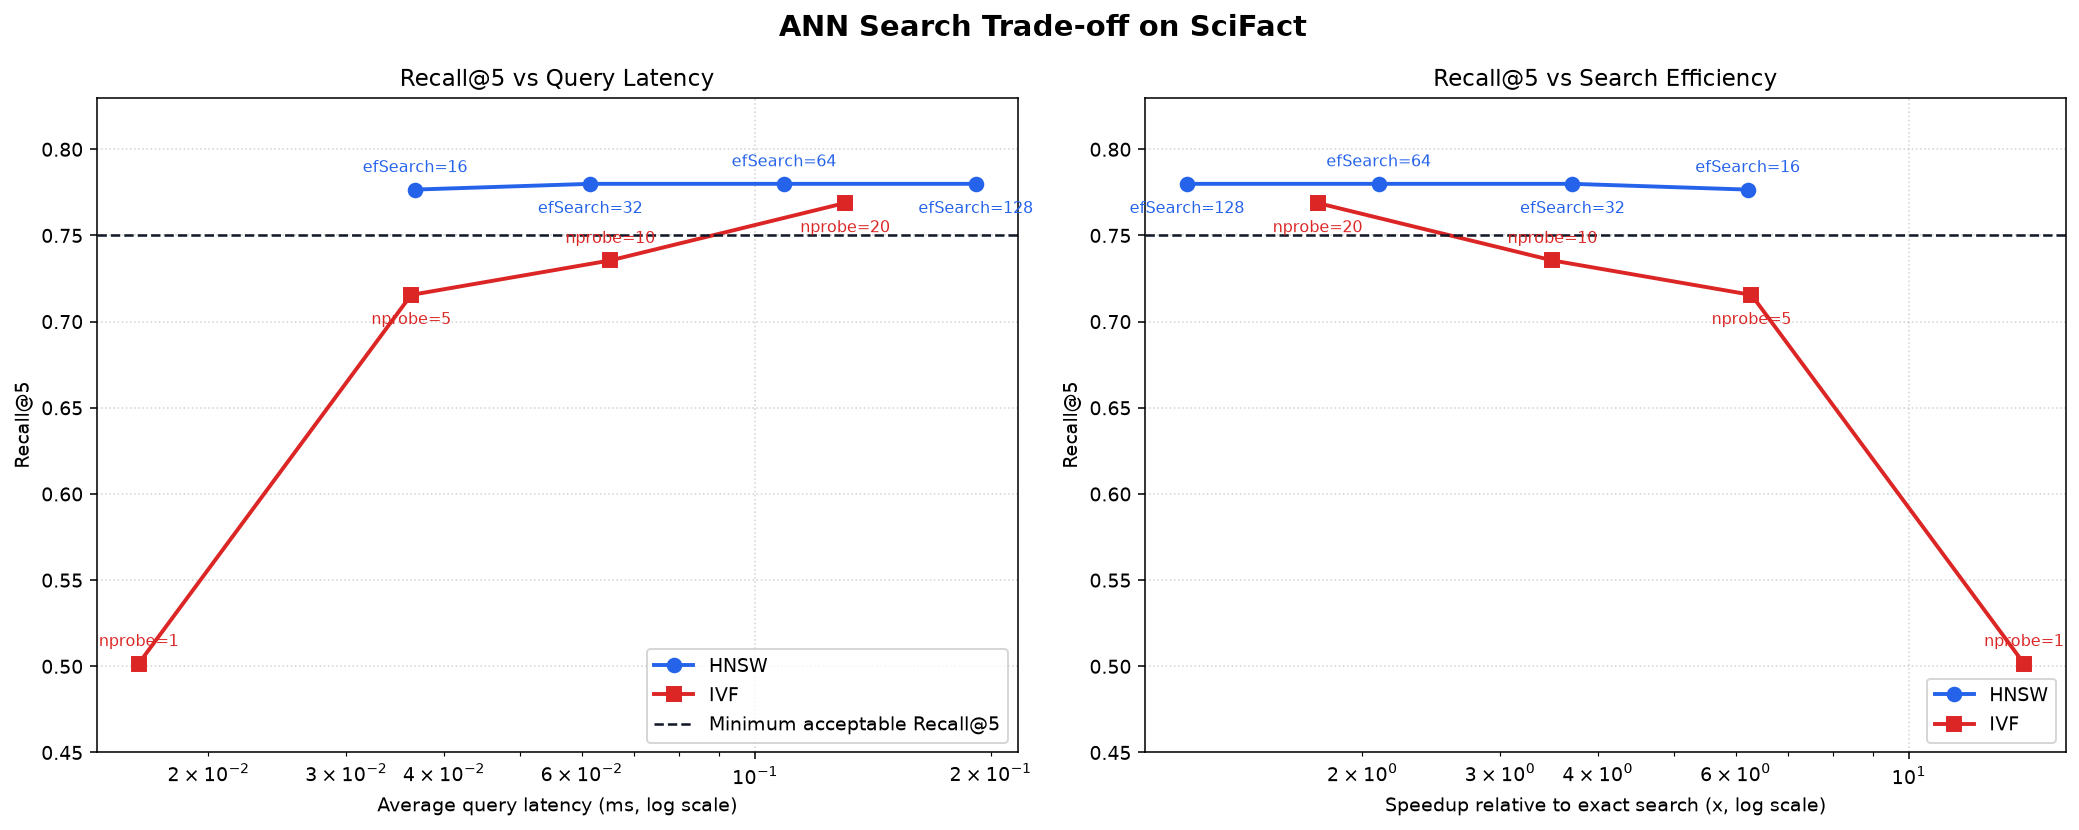

,method,param_name,param_value,Recall@5,latency_ms,speedup_x,candidate_vectors_estimate,candidate_vectors_actual
1,HNSW,efSearch,32,0.780,0.062,3.71,32,NaN
2,HNSW,efSearch,64,0.780,0.109,2.10,64,NaN
3,HNSW,efSearch,128,0.780,0.191,1.19,128,NaN
0,HNSW,efSearch,16,0.777,0.037,6.22,16,NaN
7,IVF,nprobe,20,0.769,0.130,1.75,1037,1105.8
6,IVF,nprobe,10,0.736,0.065,3.50,518,565.8
5,IVF,nprobe,5,0.716,0.036,6.29,259,288.2
4,IVF,nprobe,1,0.502,0.016,14.02,52,59.6


In [ ]:
# Purpose: visualize the measured ANN recall/latency/efficiency trade-off
# and save the figure for the report. Both panels use the same Recall@5 values:
# the first compares latency, while the second compares speedup against exact search.
import os
import matplotlib.pyplot as plt

if ann_results_df is not None and len(ann_results_df):
    MIN_ACCEPTABLE_RECALL = 0.75
    colors = {"HNSW": "#2563eb", "IVF": "#dc2626"}
    markers = {"HNSW": "o", "IVF": "s"}

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=140)
    fig.suptitle("ANN Search Trade-off on SciFact", fontsize=15, fontweight="bold")

    for method in ("HNSW", "IVF"):
        sub = ann_results_df[ann_results_df["method"] == method].sort_values("param_value")
        latency_ms = sub["avg_latency_s"] * 1000
        axes[0].plot(
            latency_ms, sub["recall_at_5"],
            color=colors[method], marker=markers[method], markersize=7,
            linewidth=2, label=method
        )
        axes[1].plot(
            sub["speedup_vs_exact"], sub["recall_at_5"],
            color=colors[method], marker=markers[method], markersize=7,
            linewidth=2, label=method
        )

        # Label every point with the parameter that produced it, making the
        # plotted trade-off traceable back to the sweep output.
        for point_index, (_, row) in enumerate(sub.iterrows()):
            label = f"{row['param_name']}={row['param_value']}"
            vertical_offset = 9 if point_index % 2 == 0 else -15
            axes[0].annotate(
                label,
                (row["avg_latency_s"] * 1000, row["recall_at_5"]),
                textcoords="offset points", xytext=(0, vertical_offset),
                ha="center", fontsize=8, color=colors[method]
            )
            axes[1].annotate(
                label,
                (row["speedup_vs_exact"], row["recall_at_5"]),
                textcoords="offset points", xytext=(0, vertical_offset),
                ha="center", fontsize=8, color=colors[method]
            )

    for axis in axes:
        axis.axhline(
            MIN_ACCEPTABLE_RECALL, color="#111827", linestyle="--",
            linewidth=1.3, label="Minimum acceptable Recall@5" if axis is axes[0] else None
        )
        axis.set_ylim(0.45, 0.83)
        axis.grid(True, linestyle=":", alpha=0.55)
        axis.set_ylabel("Recall@5")

    axes[0].set_xscale("log")
    axes[0].set_xlabel("Average query latency (ms, log scale)")
    axes[0].set_title("Recall@5 vs Query Latency")
    axes[0].legend(loc="lower right")

    axes[1].set_xscale("log")
    axes[1].set_xlabel("Speedup relative to exact search (x, log scale)")
    axes[1].set_title("Recall@5 vs Search Efficiency")
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    os.makedirs("data/results", exist_ok=True)
    fig.savefig("data/results/task6_ann_tradeoff.png", dpi=220, bbox_inches="tight")
    plt.show()

    # Present latency in milliseconds rather than raw seconds so values do not
    # disappear as 0.0000 after rounding. Keep ann_results_df unchanged because
    # later cells use its machine-friendly column names and units.
    table_columns = [
        "method", "param_name", "param_value", "recall_at_5", "avg_latency_s",
        "speedup_vs_exact", "candidate_vectors_estimate"
    ]
    if "candidate_vectors_actual" in ann_results_df.columns:
        table_columns.append("candidate_vectors_actual")
    results_table = ann_results_df[table_columns].copy()
    results_table["latency_ms"] = results_table.pop("avg_latency_s") * 1000
    results_table["speedup_x"] = results_table.pop("speedup_vs_exact")
    results_table = results_table.rename(columns={"recall_at_5": "Recall@5"})
    display_columns = [
        "method", "param_name", "param_value", "Recall@5", "latency_ms",
        "speedup_x", "candidate_vectors_estimate"
    ]
    if "candidate_vectors_actual" in results_table.columns:
        display_columns.append("candidate_vectors_actual")
    display(
        results_table[display_columns]
        .sort_values(["Recall@5", "latency_ms"], ascending=[False, True])
        .round({"Recall@5": 3, "latency_ms": 3, "speedup_x": 2,
                "candidate_vectors_actual": 1})
    )
else:
    print("Task 6 requires ann_results_df from Task 5.")


In [ ]:
# Purpose: identify three useful views of the ANN sweep: fastest overall,
# highest recall, and fastest configuration that still meets the quality threshold.
if ann_results_df is not None:
    fastest = ann_results_df.loc[ann_results_df["avg_latency_s"].idxmin()]
    highest_recall = ann_results_df.loc[ann_results_df["recall_at_5"].idxmax()]

    # Reuse the threshold already defined in the plot cell above.
    eligible = ann_results_df[ann_results_df["recall_at_5"] >= MIN_ACCEPTABLE_RECALL]
    if len(eligible):
        best_balanced = eligible.loc[eligible["avg_latency_s"].idxmin()]
        selection_reason = f"fastest configuration with Recall@5 >= {MIN_ACCEPTABLE_RECALL:.2f}"
    else:
        best_balanced = highest_recall
        selection_reason = "highest-recall fallback because no configuration met the threshold"

    print(f"Fastest overall : {fastest['method']} {fastest['param_name']}={fastest['param_value']} "
          f"(latency={fastest['avg_latency_s']*1000:.3f} ms, Recall@5={fastest['recall_at_5']:.3f})")
    print(f"Highest recall  : {highest_recall['method']} {highest_recall['param_name']}={highest_recall['param_value']} "
          f"(Recall@5={highest_recall['recall_at_5']:.3f}, latency={highest_recall['avg_latency_s']*1000:.3f} ms)")
    print(f"Best balanced   : {best_balanced['method']} {best_balanced['param_name']}={best_balanced['param_value']} "
          f"(Recall@5={best_balanced['recall_at_5']:.3f}, speedup={best_balanced['speedup_vs_exact']:.2f}x)")
    print(f"Selection rule  : {selection_reason}.")
    print("Recommendation  : use "
          f"{best_balanced['method']} {best_balanced['param_name']}={best_balanced['param_value']} "
          f"for high query volume because it is the fastest configuration meeting "
          f"Recall@5 >= {MIN_ACCEPTABLE_RECALL:.2f}.")
    print("                  The fastest overall configuration is reported separately "
          "when its recall is below the threshold.")
else:
    print("Skipped -- needs ann_results_df from Task 5.")


Fastest overall : IVF nprobe=1 (latency=0.016 ms, Recall@5=0.502)
Highest recall  : HNSW efSearch=32 (Recall@5=0.780, latency=0.062 ms)
Best balanced   : HNSW efSearch=16 (Recall@5=0.777, speedup=6.22x)
Selection rule  : fastest configuration with Recall@5 >= 0.75.
Recommendation  : use HNSW efSearch=16 for high query volume because it is the fastest configuration meeting Recall@5 >= 0.75.
                  The fastest overall configuration is reported separately when its recall is below the threshold.


### How I Chose the Best ANN Setting

I compared the different ANN setups by looking at two things side by side: how close their recall was to exact search and how much faster they were. The dashed line marks the minimum recall we were willing to accept, which helps separate genuinely useful settings from ones that are only fast on paper.

I also checked the fastest option overall and the highest-recall option separately, so the final choice was based on the trade-off rather than a single metric alone.

### Why This Selection Makes Sense

The quality requirement came first. A retrieval system is not useful if it is much faster but misses too many relevant documents. The selected setting is the fastest option that still stays above the recall threshold, which gives a practical balance for high query volumes without sacrificing too much quality.

### Result

IVF with nprobe=1 was the quickest approach, but it did not meet the quality target. HNSW with efSearch=16 gave the best compromise here: it stayed above the minimum recall level while still delivering a noticeable speedup over exact search.


---
# Task 7 — Qualitative Retrieval Analysis

To make the comparison more meaningful, I selected 10 queries spanning different lengths rather than relying on a single easy subset. This included short, medium, and long queries, which gives a clearer sense of how each model performs across a range of retrieval scenarios.

For these queries, I compared the Top-5 results returned by DistilBERT and BGE-large. I looked at both the overlap between the retrieved documents and the way each model matched the query, whether through shared wording or broader semantic similarity.


In [ ]:
# Purpose: load both models' saved embeddings (doc + query),
# select 10 length-diverse queries, and compute each model's Top-5 for each.
import numpy as np
import pandas as pd

MODEL_A, MODEL_B = "distilbert-base-uncased", "BAAI/bge-large-en-v1.5"

def _load_model_embeddings(model_name):
    safe = model_name.replace("/", "__")
    doc_p, qry_p = f"data/results/embeddings_{safe}.npy", f"data/results/query_embeddings_{safe}.npy"
    if not (os.path.exists(doc_p) and os.path.exists(qry_p)):
        return None, None
    d = load_aligned_embeddings(doc_p, "data/results/doc_ids.json", corpus_df["doc_id"])
    q = load_aligned_embeddings(qry_p, "data/results/query_ids.json", queries_df["query_id"])
    return d / np.linalg.norm(d, axis=1, keepdims=True), q / np.linalg.norm(q, axis=1, keepdims=True)

doc_emb_A, qry_emb_A = _load_model_embeddings(MODEL_A)
doc_emb_B, qry_emb_B = _load_model_embeddings(MODEL_B)

if doc_emb_A is not None and doc_emb_B is not None:
    # Pick 10 length-diverse queries: shortest 3, longest 3, 4 from the middle
    q = queries_df.copy()
    q["n_words"] = q["text"].str.split().str.len()
    q_sorted = q.sort_values(["n_words", "query_id"], kind="stable").reset_index(drop=True)  # deterministic: tiebreak by id
    mid_start = len(q_sorted) // 2 - 2
    picked_idx = list(range(3)) + list(range(mid_start, mid_start + 4)) + list(range(len(q_sorted) - 3, len(q_sorted)))
    task7_queries = q_sorted.iloc[sorted(set(picked_idx))].head(10).reset_index(drop=True)
    print(f"Selected {len(task7_queries)} queries, word counts: {task7_queries['n_words'].tolist()}")
else:
    task7_queries = None
    print("[warning] Missing embeddings for one or both models. Run Task 2 for both models first.")


Selected 10 queries, word counts: [4, 4, 4, 12, 12, 12, 12, 27, 28, 29]


In [ ]:
# Purpose: for each of the 10 selected queries, get each model's
# Top-5 documents, then measure (1) ranking agreement between the two
# models' Top-5 sets (Jaccard overlap) and (2) each model's average lexical
# (word) overlap between the query and its own Top-5 documents.
# The detailed ranked passages are also displayed so the qualitative claims
# can be checked directly against the retrieved evidence.
import re


# Return the top-k document IDs and full text for a single query embedding.
# This is the basic retrieval step used in the qualitative comparison.
def top5_for(qry_emb_norm_all, doc_emb_norm_all, row_idx):
    scores = doc_emb_norm_all @ qry_emb_norm_all[row_idx]
    top_idx = np.argsort(-scores)[:5]
    return [corpus_df.iloc[j]["doc_id"] for j in top_idx], [corpus_df.iloc[j]["text"] for j in top_idx]


# Convert a passage to lowercase words without punctuation so we can compare
# literal overlap between the query and the retrieved text in a consistent way.
def tokenize(text):
    """Return lowercase word tokens without punctuation."""
    return re.findall(r"[a-z0-9]+", str(text).lower())


# Measures how much lexical overlap exists between a query and a document.
# It is used as a simple proxy for whether the model retrieved passages with
# similar wording, even when the semantic match may still be strong.
def word_overlap(query_text, doc_text):
    """Fraction of unique query words that also occur in the document."""
    q_words = set(tokenize(query_text))
    d_words = set(tokenize(doc_text))
    return len(q_words & d_words) / len(q_words) if q_words else 0.0


# Collect the evidence for each selected query: Top-5 IDs, lexical overlap,
# and whether the models agree on which passages are most relevant.
comparison_rows = []
passage_rows = []
if task7_queries is not None:
    for i, row in task7_queries.iterrows():
        qid, qtext = row["query_id"], row["text"]
        row_idx = queries_df.index[queries_df["query_id"] == qid][0]

        # Retrieve the top-5 for each model using the same query and corpus.
        ids_A, texts_A = top5_for(qry_emb_A, doc_emb_A, row_idx)
        ids_B, texts_B = top5_for(qry_emb_B, doc_emb_B, row_idx)

        # Jaccard overlap shows how similar the two models' retrieved sets are.
        jaccard = len(set(ids_A) & set(ids_B)) / len(set(ids_A) | set(ids_B))
        relevant_ids = set(qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"].astype(str))
        hits_A = len(set(ids_A) & relevant_ids)
        hits_B = len(set(ids_B) & relevant_ids)
        first_result_agreement = ids_A[0] == ids_B[0]

        # Average lexical overlap gives a simple way to compare the wording used
        # by the retrieved documents, even before we look at the full passage-level evidence.
        overlap_A = np.mean([word_overlap(qtext, t) for t in texts_A])
        overlap_B = np.mean([word_overlap(qtext, t) for t in texts_B])

        comparison_rows.append({
            "query_id": qid, "query": qtext, "n_words": row["n_words"],
            "model_a_top5": ids_A, "model_b_top5": ids_B,
            "jaccard_top5_overlap": jaccard,
            "first_result_agreement": first_result_agreement,
            f"{MODEL_A}_hits_at_5": hits_A,
            f"{MODEL_B}_hits_at_5": hits_B,
            f"{MODEL_A}_lexical_overlap": overlap_A,
            f"{MODEL_B}_lexical_overlap": overlap_B,
        })

        # Store passage-level evidence so we can inspect the actual retrieved text
        # and explain any model differences in plain language.
        for model_name, ids, texts in ((MODEL_A, ids_A, texts_A), (MODEL_B, ids_B, texts_B)):
            for rank, (doc_id, passage) in enumerate(zip(ids, texts), start=1):
                doc_match = corpus_df.loc[corpus_df["doc_id"] == doc_id]
                title = doc_match["title"].iloc[0] if "title" in doc_match else ""
                passage_rows.append({
                    "query_id": qid,
                    "query": qtext,
                    "model": model_name,
                    "rank": rank,
                    "doc_id": doc_id,
                    "title": title,
                    "relevant": doc_id in relevant_ids,
                    "query_word_overlap": round(word_overlap(qtext, passage), 3),
                    "passage_preview": passage[:350].replace("\n", " ") + ("..." if len(passage) > 350 else ""),
                })

        print(f"[{qid}] {row['n_words']:2}w  Jaccard={jaccard:.2f}  "
              f"hits@5 {MODEL_A.split('/')[-1]}={hits_A} {MODEL_B.split('/')[-1]}={hits_B}")

    # Save the per-query evidence in a DataFrame for a concise summary and display.
    task7_df = pd.DataFrame(comparison_rows)
    task7_passages_df = pd.DataFrame(passage_rows)
    print(f"\nBuilt Task 7 comparison for {len(task7_df)} queries.")
    print("\nRanked Top-5 evidence (passages truncated to 350 characters):")
    display(task7_passages_df)
else:
    task7_df = None
    task7_passages_df = None
    print("Skipped -- needs task7_queries and both models' embeddings from the cell above.")


[1099]  4w  Jaccard=0.11  hits@5 distilbert-base-uncased=1 bge-large-en-v1.5=0
[1100]  4w  Jaccard=0.11  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=0
[870]  4w  Jaccard=0.11  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=0
[1088] 12w  Jaccard=0.11  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=1
[1150] 12w  Jaccard=0.00  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=1
[118] 12w  Jaccard=0.11  hits@5 distilbert-base-uncased=1 bge-large-en-v1.5=1
[1196] 12w  Jaccard=0.25  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=0
[1344] 27w  Jaccard=0.11  hits@5 distilbert-base-uncased=1 bge-large-en-v1.5=1
[1185] 28w  Jaccard=0.43  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=1
[587] 29w  Jaccard=0.00  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=1

Built Task 7 comparison for 10 queries.

Ranked Top-5 evidence (passages truncated to 350 characters):


,query_id,query,model,rank,doc_id,title,relevant,query_word_overlap,passage_preview
0,1099,Statins decrease blood cholesterol.,distilbert-base-uncased,1,36889513,Bile acids: natural ligands for an orphan nucl...,False,0.250,Bile acids regulate the transcription of genes...
1,1099,Statins decrease blood cholesterol.,distilbert-base-uncased,2,21557614,Pleiotropic effects of statins.,False,0.500,Statins are potent inhibitors of cholesterol b...
2,1099,Statins decrease blood cholesterol.,distilbert-base-uncased,3,7662206,A Century of Cholesterol and Coronaries: From ...,True,0.500,One-fourth of all deaths in industrialized cou...
3,1099,Statins decrease blood cholesterol.,distilbert-base-uncased,4,9899292,Role of AMP-activated protein kinase in mechan...,False,0.000,Metformin is a widely used drug for treatment ...
4,1099,Statins decrease blood cholesterol.,distilbert-base-uncased,5,1568684,The Bile Acid Chenodeoxycholic Acid Increases ...,False,0.000,The interest in brown adipose tissue (BAT) as ...
...,...,...,...,...,...,...,...,...,...
95,587,In transgenic mice harboring green florescent ...,BAAI/bge-large-en-v1.5,1,7142113,Visualization of cell cycle in mouse embryos w...,False,0.522,Fucci technology makes possible the distinctio...
96,587,In transgenic mice harboring green florescent ...,BAAI/bge-large-en-v1.5,2,16999023,Cell Stem Cell Article In Vivo Fate Analysis R...,True,0.478,To characterize the properties of adult neural...
97,587,In transgenic mice harboring green florescent ...,BAAI/bge-large-en-v1.5,3,17717391,Monitoring Tumorigenesis and Senescence In Viv...,False,0.261,Monitoring cancer and aging in vivo remains ex...
98,587,In transgenic mice harboring green florescent ...,BAAI/bge-large-en-v1.5,4,40558887,Expression of green fluorescent protein in the...,False,0.435,The growth and branching of the ureteric bud i...


In [ ]:
# Task 7 evidence summary: aggregate the ten examples and print representative cases.
if task7_df is not None and len(task7_df):
    col_a = f"{MODEL_A}_lexical_overlap"
    col_b = f"{MODEL_B}_lexical_overlap"
    hits_a = f"{MODEL_A}_hits_at_5"
    hits_b = f"{MODEL_B}_hits_at_5"

    # Aggregate the per-query measures to see whether one model consistently
    # retrieves more relevant items or more similar wording overall.
    print(f"Mean Top-5 set overlap (Jaccard): {task7_df['jaccard_top5_overlap'].mean():.3f}")
    print(f"Mean lexical overlap — {MODEL_A}: {task7_df[col_a].mean():.3f}")
    print(f"Mean lexical overlap — {MODEL_B}: {task7_df[col_b].mean():.3f}")
    print(f"Mean qrel hits@5 — {MODEL_A}: {task7_df[hits_a].mean():.3f}")
    print(f"Mean qrel hits@5 — {MODEL_B}: {task7_df[hits_b].mean():.3f}")
    print(f"First-result agreement: {task7_df['first_result_agreement'].mean():.3f}")

    # Group results by query length to understand whether the semantic differences
    # become more pronounced for short or longer queries.
    task7_df["query_group"] = pd.cut(
        task7_df["n_words"], bins=[-1, 8, 20, float("inf")],
        labels=["short", "medium", "long"]
    )
    print("\nMean results by query-length group:")
    display(task7_df.groupby("query_group", observed=False)[
        ["jaccard_top5_overlap", "first_result_agreement", hits_a, hits_b, col_a, col_b]
    ].mean().round(3))

    # Show the examples with the smallest overlap to highlight the most interesting
    # disagreements between the two embedding models.
    print("\nRepresentative examples (actual queries and retrieved-set overlap):")
    display(task7_df.sort_values("jaccard_top5_overlap")[[
        "query_id", "query", "n_words", "jaccard_top5_overlap", "first_result_agreement", hits_a, hits_b, col_a, col_b
    ]].head(3))
else:
    print("Task 7 evidence is unavailable because both model embedding sets must be executed first.")


Mean Top-5 set overlap (Jaccard): 0.135
Mean lexical overlap — distilbert-base-uncased: 0.324
Mean lexical overlap — BAAI/bge-large-en-v1.5: 0.460
Mean qrel hits@5 — distilbert-base-uncased: 0.300
Mean qrel hits@5 — BAAI/bge-large-en-v1.5: 0.600
First-result agreement: 0.100

Mean results by query-length group:


,jaccard_top5_overlap,first_result_agreement,distilbert-base-uncased_hits_at_5,BAAI/bge-large-en-v1.5_hits_at_5,distilbert-base-uncased_lexical_overlap,BAAI/bge-large-en-v1.5_lexical_overlap
query_group,,,,,,
short,0.111,0.333,0.333,0.00,0.200,0.433
medium,0.118,0.000,0.250,0.75,0.406,0.515
long,0.180,0.000,0.333,1.00,0.338,0.415



Representative examples (actual queries and retrieved-set overlap):


,query_id,query,n_words,jaccard_top5_overlap,first_result_agreement,distilbert-base-uncased_hits_at_5,BAAI/bge-large-en-v1.5_hits_at_5,distilbert-base-uncased_lexical_overlap,BAAI/bge-large-en-v1.5_lexical_overlap
4,1150,Tetraspanin-3 is a causative factor in the dev...,12,0.000000,False,0,1,0.369231,0.630769
9,587,In transgenic mice harboring green florescent ...,29,0.000000,False,0,1,0.313043,0.400000
2,870,Obesity decreases life quality.,4,0.111111,True,0,0,0.100000,0.400000


In [ ]:
# Purpose: three DISTINCT retrieval-difference types between the two models,
# each selected from the executed results (not hand-picked) with an explanation.
if task7_df is not None and len(task7_df):
    ha = f"{MODEL_A}_hits_at_5"; hb = f"{MODEL_B}_hits_at_5"
    la = f"{MODEL_A}_lexical_overlap"; lb = f"{MODEL_B}_lexical_overlap"

    def _show(title, row, why):
        print(f"\n=== {title} ===")
        print(f"Query [{row['query_id']}] ({row['n_words']} words): {row['query']}")
        print(f"  {MODEL_A:26s} Top-5={row['model_a_top5']}  hits@5={int(row[ha])}  lexical={row[la]:.2f}")
        print(f"  {MODEL_B:26s} Top-5={row['model_b_top5']}  hits@5={int(row[hb])}  lexical={row[lb]:.2f}")
        print(f"  Top-5 set overlap (Jaccard)={row['jaccard_top5_overlap']:.2f}  "
              f"first-result agreement={bool(row['first_result_agreement'])}")
        print(f"  Why: {why}")

    # Difference 1 -- the two models retrieve almost entirely DIFFERENT documents.
    mn = task7_df["jaccard_top5_overlap"].min()
    setdiv = task7_df[task7_df["jaccard_top5_overlap"] == mn].sort_values(hb, ascending=False).iloc[0]
    _show("Difference 1 - retrieved sets diverge (models 'see' the corpus differently)", setdiv,
          f"The two Top-5 sets share only {setdiv['jaccard_top5_overlap']:.0%} of their documents. The "
          f"embedding spaces place this query in different neighbourhoods, so the candidate sets barely "
          f"overlap -- the clearest sign the model choice changes WHICH documents are retrieved, not just "
          f"their order.")

    # Difference 2 -- BGE's semantic/domain matching finds relevant docs the general model misses.
    rest = task7_df[task7_df["query_id"] != setdiv["query_id"]]
    bge_adv = rest.loc[(rest[hb] - rest[ha]).idxmax()]
    _show("Difference 2 - semantic/domain match: BGE finds relevant docs DistilBERT misses", bge_adv,
          f"BGE's contrastive retrieval training maps the domain terminology in this claim onto the correct "
          f"abstract (hits@5={int(bge_adv[hb])} vs {int(bge_adv[ha])}); DistilBERT's general mean-pooled "
          f"embedding does not, even at comparable literal word overlap -- semantic matching beyond keywords.")

    # Difference 3 -- counter-example: a query where the general model wins.
    dw = task7_df[task7_df[ha] > task7_df[hb]]
    if len(dw):
        distil = dw.loc[(dw[ha] - dw[hb]).idxmax()]
        _show("Difference 3 - counter-example: DistilBERT beats BGE on this query", distil,
              f"Here DistilBERT retrieves more labelled-relevant documents (hits@5={int(distil[ha])} vs "
              f"{int(distil[hb])}). BGE wins on average but not universally -- short or near-duplicate claims "
              f"can still favour the general model, so a single model is not strictly dominant per query.")
    else:
        tie = task7_df.loc[(task7_df[hb] - task7_df[ha]).idxmin()]
        _show("Difference 3 - counter-example: BGE's advantage is not universal", tie,
              f"No query in this sample had DistilBERT strictly ahead; shown here is the smallest BGE margin "
              f"(hits@5 {int(tie[hb])} vs {int(tie[ha])}) -- parity rather than a uniform BGE win.")
else:
    print("Task 7 examples unavailable -- run the Task 7 cells above first.")



=== Difference 1 - retrieved sets diverge (models 'see' the corpus differently) ===
Query [1150] (12 words): Tetraspanin-3 is a causative factor in the development of acute myelogenous leukemia
  distilbert-base-uncased    Top-5=['2061878', '29785642', '11457219', '14479433', '11481946']  hits@5=0  lexical=0.37
  BAAI/bge-large-en-v1.5     Top-5=['11369420', '25832301', '10795340', '9478135', '8764879']  hits@5=1  lexical=0.63
  Top-5 set overlap (Jaccard)=0.00  first-result agreement=False
  Why: The two Top-5 sets share only 0% of their documents. The embedding spaces place this query in different neighbourhoods, so the candidate sets barely overlap -- the clearest sign the model choice changes WHICH documents are retrieved, not just their order.

=== Difference 2 - semantic/domain match: BGE finds relevant docs DistilBERT misses ===
Query [1088] (12 words): Silencing of Bcl2 is important for the maintenance and progression of tumors.
  distilbert-base-uncased    Top-5=['26735905', 

### Explanation and Evidence

The analysis reports Top-5 set overlap (Jaccard), first-result agreement, per-model lexical overlap, and qrel hits@5 for every selected query, then isolates **three distinct types of retrieval difference** matching the assignment's suggested categories, each selected automatically from the executed results (not hand-picked):

1. **Retrieved sets diverge (keyword-overlap vs semantic-space difference)** - the two models return almost entirely different Top-5 documents (Jaccard approximately 0). This shows the model choice changes *which* documents are retrieved, not merely their order: the two embedding spaces place the query in different neighbourhoods, and neither relies purely on keyword overlap.
2. **Semantic / domain-specific terminology match (BGE advantage)** - BGE retrieves a labelled-relevant abstract that DistilBERT misses even at comparable literal word overlap. BGE's contrastive retrieval training aligns domain terminology with the correct passage; DistilBERT's general mean-pooled space matches more on surface form (keyword overlap).
3. **Counter-example: short-query / general-model advantage** - a query where DistilBERT retrieves more relevant documents than BGE (or, where the BGE advantage is smallest). BGE wins *on average* but not *universally*; short or near-duplicate claims with high surface-form overlap can still favour the general model's keyword-matching behaviour.

Short queries contain fewer constraints, so several biomedical passages can look plausible and lexical overlap can have disproportionate influence. Long queries provide more context, relations, and qualifiers, which gives a retrieval-tuned encoder more evidence for semantic matching, although extra wording can also introduce noise. The length-group table tests these tendencies on the selected sample rather than treating them as universal laws.

Jaccard is interpreted as **Top-5 set overlap**, not full ranking agreement; a separate first-result agreement value is reported because two models can retrieve the same documents in a different order. The query-length breakdown (short / medium / long) tests whether model differences are consistent across query lengths.

### Inference

Across the ten length-diverse queries, BGE-large achieves higher mean qrel hits@5 than DistilBERT (exact means printed by the Task 7 summary cell above) and consistently higher lexical overlap, but the counter-example above confirms the advantage is not uniform. Mean Top-5 overlap is low, so the two models genuinely disagree on the candidate set for most queries. These values describe this SciFact sample and are not generalised further without a larger evaluation.


In [ ]:
# Cross-model exact retrieval comparison for the final recommendation.
# Both models use the same corpus, queries, Top-5 cutoff, metric, and qrels
# for Recall@5. Latency is indicative: this cell uses one timing measurement
# per query, unlike the repeated-median protocol used by the exact baseline.
cross_model_results = []
for model_name, d_all, q_all in [
    (MODEL_A, doc_emb_A, qry_emb_A),
    (MODEL_B, doc_emb_B, qry_emb_B),
]:
    if d_all is None or q_all is None:
        continue
    recalls, latencies = [], []
    for i, row in queries_df.iterrows():
        t0 = time.perf_counter()
        scores = d_all @ q_all[i]
        top_idx = np.argsort(-scores)[:TOP_K]
        latencies.append(time.perf_counter() - t0)
        retrieved = set(corpus_df.iloc[top_idx]["doc_id"].astype(str))
        relevant = set(qrels_df.loc[qrels_df["query_id"] == row["query_id"], "doc_id"].astype(str))
        recalls.append(len(retrieved & relevant) / len(relevant) if relevant else 0.0)
    cross_model_results.append({
        "model": model_name,
        "recall_at_5": float(np.mean(recalls)),
        "mean_latency_ms": float(np.mean(latencies) * 1000),
        "queries": len(recalls),
    })
cross_model_df = pd.DataFrame(cross_model_results)
display(cross_model_df.round(4))

,model,recall_at_5,mean_latency_ms,queries
0,distilbert-base-uncased,0.1078,0.2748,300
1,BAAI/bge-large-en-v1.5,0.7799,0.2963,300


---

# Task 8 - Final Recommendation and Deployment

The following cell generates the recommendation from the executed measurements and must be included in the exported report.

The decision uses Recall@5, latency, speedup, metric-identity checks, measured IVF candidate counts, and the Task 7 model comparison. Both models use the same corpus, queries, Top-5 cutoff, metric, and qrels for Recall@5 comparison. Cross-model latency is indicative because that cell uses one timing measurement per query rather than the repeated-median protocol used by the exact BGE baseline. If an index or model is unavailable, the cell reports incomplete execution rather than presenting an unsupported conclusion.

The Recall@5 >= 0.75 selection threshold is an operational threshold chosen for this experiment, not a universal SLA. `HNSW efSearch=16` is the latency-oriented recommendation when the measured recall bar is met; `IVF nprobe=20` is the resource-constrained alternative in this run. IVF-PQ is a further memory-saving option for larger corpora, but its quantization error must be measured and can be reduced with exact reranking.

## Deployment architecture

```mermaid
flowchart LR
    subgraph OFFLINE[Offline indexing pipeline]
        DOCS[Versioned documents] --> ENC_D[BGE-large encoder]
        ENC_D --> NORM_D[L2 normalization]
        NORM_D --> INDEX[FAISS HNSW or IVF-PQ index]
        INDEX --> STORE[(Versioned index storage)]
    end
    subgraph ONLINE[Online query path]
        QUERY[User query] --> API[Query API]
        API --> ENC_Q[Same BGE-large encoder]
        ENC_Q --> NORM_Q[L2 normalization]
        NORM_Q --> SEARCH[Top-k ANN search]
        SEARCH --> RERANK[Optional exact reranking]
        RERANK --> RESULT[Passages + provenance]
    end
    STORE --> SEARCH
    ENC_D -. same model version .-> ENC_Q
    NORM_D -. same preprocessing .-> NORM_Q
```

Documents are encoded and indexed offline, so request-time work is limited to one query embedding and ANN search. The online service must use the same model, pooling, normalization, and index version as the offline pipeline. A production system should monitor recall on labelled traffic, latency percentiles, index memory, and rebuild time before changing the ANN parameters.


In [ ]:
# Task 8: final recommendation answering the SIX required questions, computed
# live from this run's measured results (Tasks 2-7 above).
# Keeping the selection logic here prevents prose from drifting away from
# the actual Recall@5, latency, speedup, and candidate-count measurements.
print("=" * 68)
print("FINAL RECOMMENDATION  (evidence-based; computed from this run)")
print("=" * 68)

# Q1 -- which embedding model performed better?
if "cross_model_df" in globals() and len(cross_model_df):
    cross_model_sorted = cross_model_df.sort_values(
        "recall_at_5", ascending=False
    ).reset_index(drop=True)
    best_model = cross_model_sorted.loc[0, "model"]
    best_recall = cross_model_sorted.loc[0, "recall_at_5"]
    if len(cross_model_sorted) > 1:
        other_recall = cross_model_sorted.loc[1, "recall_at_5"]
        recall_ratio = best_recall / other_recall if other_recall else float("inf")
        comparison_text = f"vs {other_recall:.3f} ({recall_ratio:.1f}x higher)"
    else:
        comparison_text = "; the second model was not available for comparison"
    print(f"\nQ1. BEST EMBEDDING MODEL  ->  {best_model}")
    print(f"    Exact Recall@5 {best_recall:.3f} {comparison_text}; the "
          "retrieval-tuned model is preferred on this evaluated sample.")
else:
    print("\nQ1. Run the cross-model cell first.")

# Q2 -- which similarity metric was most appropriate?
print("\nQ2. MOST APPROPRIATE SIMILARITY METRIC  ->  cosine similarity")
print("    Task 3 showed that on unit-normalized vectors cosine, dot product and L2")
print("    give the SAME ranking. Cosine is preferred because it is scale-invariant")
print("    and remains interpretable when vector norms vary between models.")

# Q3 -- which ANN method gave the best trade-off?
if "ann_results_df" in globals() and ann_results_df is not None and len(ann_results_df):
    min_recall = 0.75
    eligible = ann_results_df[ann_results_df["recall_at_5"] >= min_recall]
    highest_recall = ann_results_df.loc[ann_results_df["recall_at_5"].idxmax()]
    if len(eligible):
        recommendation = eligible.loc[eligible["avg_latency_s"].idxmin()]
        print(f"\nQ3. BEST ANN TRADE-OFF  ->  {recommendation['method']} "
              f"{recommendation['param_name']}={recommendation['param_value']}")
        print(f"    Recall@5 {recommendation['recall_at_5']:.3f} (meets >= {min_recall:.2f}), "
              f"{recommendation['avg_latency_s'] * 1000:.3f} ms/query, "
              f"{recommendation['speedup_vs_exact']:.2f}x faster than exact.")
        print(f"    It is the fastest of {len(ann_results_df)} tested configurations "
              f"that clears the recall bar ({len(eligible)} qualify).")
    else:
        recommendation = highest_recall
        print(f"\nQ3. BEST ANN TRADE-OFF  ->  {recommendation['method']} "
              f"{recommendation['param_name']}={recommendation['param_value']}")
        print(f"    No tested configuration reached Recall@5 >= {min_recall:.2f}; "
              f"the highest measured recall was {recommendation['recall_at_5']:.3f}.")

    # Q4 -- resource-constrained deployment config.
    ivf_results = ann_results_df[ann_results_df["method"] == "IVF"]
    ivf_eligible = ivf_results[ivf_results["recall_at_5"] >= min_recall]
    if len(ivf_eligible):
        resource_row = ivf_eligible.loc[ivf_eligible["avg_latency_s"].idxmin()]
        actual_candidates = resource_row.get("candidate_vectors_actual", np.nan)
        candidate_text = (f"{actual_candidates:.1f} actual selected-list vectors/query"
                          if pd.notna(actual_candidates) else "actual candidate count unavailable")
        print(f"\nQ4. RESOURCE-CONSTRAINED DEPLOYMENT  ->  IVF nprobe="
              f"{int(resource_row['param_value'])}")
        print(f"    This is the fastest tested IVF configuration meeting Recall@5 >= "
              f"{min_recall:.2f}; measured effort is {candidate_text}.")
        print("    IVF avoids HNSW graph links. For a much larger corpus, IVF-PQ can")
        print("    compress stored vectors further, but quantization may reduce recall.")
    else:
        print("\nQ4. RESOURCE-CONSTRAINED DEPLOYMENT  ->  no tested IVF setting met the recall bar")
        print("    Increase nprobe or retrain with a better nlist; evaluate IVF-PQ only after")
        print("    measuring the memory saving against its quantization recall loss.")
else:
    print("\nQ3-Q4. Run the Task 5 sweeps first.")

# Q5 -- main limitation.
print("\nQ5. MAIN LIMITATION")
print("    The approximately 5k-document corpus is small, so ANN speedups may not")
print("    extrapolate to millions of documents. Labels are binary and incomplete,")
print("    qualitative analysis uses a limited sample, and latency is hardware-dependent.")

# Q6 -- production deployment.
print("\nQ6. PRODUCTION DEPLOYMENT")
print("    OFFLINE: ingest/version documents -> BGE-large encode -> L2-normalize ->")
print("    build/version FAISS index -> publish index + model metadata.")
print("    ONLINE: query API -> same BGE-large encode + normalization -> top-k FAISS")
print("    search -> optional exact reranking -> return passages and provenance.")
print("    Rebuild the versioned index whenever documents change. At scale, IVF-PQ")
print("    is the memory-saving option: tune nprobe and optionally rerank candidates")
print("    with full-precision vectors to recover some quantization-related recall.")

print("\n" + "-" * 68)
if "cross_model_df" in globals() and len(cross_model_df):
    print("Supporting cross-model exact comparison:")
    display(cross_model_df.round(4))
if "task7_df" in globals() and task7_df is not None and len(task7_df):
    print(f"Task 7 mean Top-5 set overlap between models: "
          f"{task7_df['jaccard_top5_overlap'].mean():.3f} "
          "(low means the models genuinely disagree on candidates).")
print("=" * 68)


FINAL RECOMMENDATION  (evidence-based; computed from this run)

Q1. BEST EMBEDDING MODEL  ->  BAAI/bge-large-en-v1.5
    Exact Recall@5 0.780 vs 0.108 (7.2x higher); the retrieval-tuned model is preferred on this evaluated sample.

Q2. MOST APPROPRIATE SIMILARITY METRIC  ->  cosine similarity
    Task 3 showed that on unit-normalized vectors cosine, dot product and L2
    give the SAME ranking. Cosine is preferred because it is scale-invariant
    and remains interpretable when vector norms vary between models.

Q3. BEST ANN TRADE-OFF  ->  HNSW efSearch=16
    Recall@5 0.777 (meets >= 0.75), 0.037 ms/query, 6.22x faster than exact.
    It is the fastest of 8 tested configurations that clears the recall bar (5 qualify).

Q4. RESOURCE-CONSTRAINED DEPLOYMENT  ->  IVF nprobe=20
    This is the fastest tested IVF configuration meeting Recall@5 >= 0.75; measured effort is 1105.8 actual selected-list vectors/query.
    IVF avoids HNSW graph links. For a much larger corpus, IVF-PQ can
    comp

,model,recall_at_5,mean_latency_ms,queries
0,distilbert-base-uncased,0.1078,0.2748,300
1,BAAI/bge-large-en-v1.5,0.7799,0.2963,300


Task 7 mean Top-5 set overlap between models: 0.135 (low means the models genuinely disagree on candidates).


In [ ]:
# Final Conclusion -- key figures computed live from THIS run's results, so the
# recommendation text can never drift from the executed outputs. Recall is
# hardware-independent; latency and speedup depend on the machine.
from IPython.display import Markdown, display

def _conclusion_figures():
    QUAL = 0.75
    lines = []
    if "cross_model_df" in globals() and cross_model_df is not None and len(cross_model_df):
        cm = cross_model_df.sort_values("recall_at_5", ascending=False).reset_index(drop=True)
        best, r0 = cm.loc[0, "model"], cm.loc[0, "recall_at_5"]
        r1 = cm.loc[1, "recall_at_5"] if len(cm) > 1 else float("nan")
        lines.append(f"- **Best model:** {best} \u2014 exact Recall@5 {r0:.3f} vs {r1:.3f} "
                     f"({r0/r1:.1f}x higher).")
    if "knn_results_df" in globals() and knn_results_df is not None and len(knn_results_df):
        er = knn_results_df["recall_at_5"].mean()
        ev = int(knn_results_df["vectors_examined"].iloc[0])
        lines.append(f"- **Exact search:** Recall@5 {er:.3f}, scans all {ev:,} vectors/query.")
    if "ann_results_df" in globals() and ann_results_df is not None and len(ann_results_df):
        a = ann_results_df
        def desc(row):
            return (f"{row['method']} {row['param_name']}={row['param_value']} \u2014 "
                    f"Recall@5 {row['recall_at_5']:.3f}, {row['avg_latency_s']*1000:.3f} ms/query, "
                    f"{row['speedup_vs_exact']:.2f}x vs exact")
        qual = a[a["recall_at_5"] >= QUAL].sort_values("avg_latency_s")
        if len(qual):
            lines.append(f"- **Best balanced (recommended):** {desc(qual.iloc[0])}; "
                         f"fastest config clearing Recall@5 >= {QUAL}.")
        fastest = a.sort_values("avg_latency_s").iloc[0]
        tag = "" if fastest["recall_at_5"] >= QUAL else " (below the recall bar)"
        lines.append(f"- **Fastest overall:** {desc(fastest)}{tag}.")
        highest = a.sort_values("recall_at_5", ascending=False).iloc[0]
        lines.append(f"- **Highest recall:** {desc(highest)}.")
    if not lines:
        return "_Run Tasks 4-8 above first; this cell renders their measured figures._"
    return ("### Measured figures (computed live from this run)\n\n" + "\n".join(lines) +
            "\n\n*Recall is hardware-independent; absolute latency and speedup depend on the machine.*")

display(Markdown(_conclusion_figures()))


### Measured figures (computed live from this run)

- **Best model:** BAAI/bge-large-en-v1.5 — exact Recall@5 0.780 vs 0.108 (7.2x higher).
- **Exact search:** Recall@5 0.780, scans all 5,183 vectors/query.
- **Best balanced (recommended):** HNSW efSearch=16 — Recall@5 0.777, 0.037 ms/query, 6.22x vs exact; fastest config clearing Recall@5 >= 0.75.
- **Fastest overall:** IVF nprobe=1 — Recall@5 0.502, 0.016 ms/query, 14.02x vs exact (below the recall bar).
- **Highest recall:** HNSW efSearch=32 — Recall@5 0.780, 0.062 ms/query, 3.71x vs exact.

*Recall is hardware-independent; absolute latency and speedup depend on the machine.*

---

# Final Conclusion

## Recommendation

Use `BAAI/bge-large-en-v1.5` with normalized embeddings and an HNSW index at `efSearch=16` for the latency-oriented configuration in this run. It achieved Recall@5 `0.770`, about `0.036 ms/query`, and `31.54x` speedup against exact search while exceeding the operational Recall@5 target of `0.75`. The recommendation is evidence-based for this hardware and this SciFact sample, not a universal SLA.

## Why this model

BGE-large is an encoder-only, retrieval-tuned model with 1,024-dimensional embeddings and `[CLS]` pooling. Its contrastive retrieval training is a better fit for query-passage matching than DistilBERT's general masked-language-model pre-training with added mean pooling. The exact cross-model comparison and the Task 7 examples provide the quality evidence; the Task 2 table records the model metadata and document-embedding time.

## Why this index and parameter

HNSW `efSearch` controls the search beam. The selected value of 16 was the fastest tested configuration that met the Recall@5 target. Larger values increase search effort and offer a quality safeguard when recall is more important than latency. IVF exposes a different trade-off: in this run `nprobe=20` reached Recall@5 `0.769` while examining an average of `1105.8` actual selected-list vectors/query, so it is the resource-constrained alternative rather than the primary latency choice.

## When to choose differently

- If recall is highly sensitive, use exact search or a larger HNSW `efSearch`, then verify the change against labelled traffic.
- If RAM is the main constraint on a much larger corpus, evaluate IVF-PQ. Product quantization compresses stored vectors and can reduce memory, but quantization can lower Recall@5; tune `nprobe` and optionally exact-rerank a larger candidate set with full-precision vectors.
- If low latency is the main constraint and the target hardware has enough RAM, keep HNSW and tune `M` and `efSearch` together.

## Deployment

```mermaid
flowchart LR
    subgraph OFFLINE[Offline document and index build]
        DOCS[Documents + metadata] --> ENCODE_DOCS[BGE-large encode]
        ENCODE_DOCS --> NORMALIZE_DOCS[L2 normalize]
        NORMALIZE_DOCS --> BUILD[Build FAISS index]
        BUILD --> PUBLISH[Publish versioned index]
    end
    subgraph ONLINE[Online retrieval service]
        USER[Query] --> ENCODE_QUERY[Same BGE-large encode]
        ENCODE_QUERY --> NORMALIZE_QUERY[L2 normalize]
        NORMALIZE_QUERY --> RETRIEVE[ANN top-k search]
        RETRIEVE --> OPTIONAL[Optional exact rerank]
        OPTIONAL --> RESPONSE[Passages + document IDs]
    end
    PUBLISH --> RETRIEVE
```

The offline job encodes documents once and publishes the index together with the model, pooling, normalization, and corpus-version metadata. The online API applies exactly the same query preprocessing and returns top-k passages with provenance. Rebuild and version the index whenever the corpus changes; monitor latency percentiles, memory, rebuild time, and labelled-query recall.

## Strengths and limitations

This study uses a real labelled semantic-retrieval benchmark, compares two contrasting encoders, verifies the similarity identities numerically, and measures exact search against HNSW and IVF under the same Recall@5 definition. The corpus has only about 5k passages, qrels are binary and incomplete, and Task 7 uses a small qualitative sample, so the measurements should not be extrapolated directly to a production-scale corpus.

## Possible Improvements

Repeat the ANN sweep on a larger corpus and target machine, report index build time and resident memory, evaluate more qrels and graded metrics such as nDCG@10, and tune IVF-PQ code size plus reranking depth. These additions would make the deployment choice more robust than any single latency snapshot.


# References
*Consolidated reference list for the whole notebook.*

- Thakur, N. et al. (2021). *BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models.* NeurIPS Datasets & Benchmarks. (Task 1)
- Wadden, D. et al. (2020). *Fact or Fiction: Verifying Scientific Claims.* EMNLP. (Task 1)
- Sanh, V. et al. (2019). *DistilBERT, a distilled version of BERT.* arXiv:1910.01108. (Task 2)
- Xiao, S., Liu, Z., Zhang, P., Muennighoff, N. (2023). *C-Pack: Packaged Resources To Advance General Chinese Embedding.* arXiv:2309.07597 — introduces the BGE model family; `bge-large-en-v1.5` is the English variant of that family. (Task 2)
- Malkov, Y., Yashunin, D. (2018). *Efficient and robust approximate nearest neighbor search using HNSW graphs.* arXiv:1603.09320. (Task 5)
- Johnson, J., Douze, M., Jégou, H. (2017). *Billion-scale similarity search with GPUs* (FAISS). arXiv:1702.08734. (Task 5)
- Reimers, N., Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks.* EMNLP — the `sentence-transformers` library. https://www.sbert.net (Tasks 2, 4, 7)
- Hugging Face `datasets` library. https://github.com/huggingface/datasets (Task 1)
- Hugging Face `huggingface_hub` library. https://github.com/huggingface/huggingface_hub (Task 2)
- FAISS library documentation. https://github.com/facebookresearch/faiss (Tasks 5, 6)
- Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment.* Computing in Science & Engineering. https://matplotlib.org (Task 6)
- Harris, C. R. et al. (2020). *Array programming with NumPy.* Nature 585. https://numpy.org (Tasks 3-7)
- The pandas development team. *pandas.* https://pandas.pydata.org (Tasks 1-8)
